<a href="https://colab.research.google.com/github/pranav662/Food_Delivery_Data_Analysis_FDS_Project/blob/main/Food_Delivery_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

# Load the dataset
csv_path = '/content/food_delivery_orders_dataset.csv'
try:
    df = pd.read_csv(csv_path)
    print("Dataset successfully loaded!")
    print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
    print("\nColumns and Data Types:")
    print(df.dtypes)
    print("\nFirst 3 rows:")
    display(df.head(3))
except Exception as e:
    print("Error loading file:", e)

Dataset successfully loaded!
Shape: 50000 rows, 37 columns

Columns and Data Types:
order_id                                object
customer_id                             object
restaurant_id                           object
driver_id                               object
order_timestamp                         object
order_date                              object
order_hour                               int64
day_of_week                             object
is_weekend                               int64
city                                    object
delivery_area                           object
customer_age                             int64
customer_type                           object
restaurant_type                         object
restaurant_primary_category             object
restaurant_rating                      float64
items_count                              int64
subtotal                               float64
discount_percent                         int64
tax_amount             

,order_id,customer_id,restaurant_id,driver_id,order_timestamp,order_date,order_hour,day_of_week,is_weekend,city,...,traffic_level,delivery_partner_experience_months,delivery_partner_rating,restaurant_preparation_time_minutes,estimated_delivery_time_minutes,actual_delivery_time_minutes,late_delivery,order_status,cancellation_reason,customer_rating
0,ORD_000001,CUS_00001,RES_0008,DRV_0075,2025-10-05 15:54:00,2025-10-05,15,Sunday,1,City_C,...,Medium,14,4.4,25,25,29.0,0.0,Completed,NaN,4.6
1,ORD_000002,CUS_00013,RES_0024,DRV_0131,2025-10-01 20:00:00,2025-10-01,20,Wednesday,0,City_A,...,High,44,4.7,12,20,24.0,0.0,Completed,NaN,5.0
2,ORD_000003,CUS_00049,RES_0013,DRV_0087,2025-10-07 18:24:00,2025-10-07,18,Tuesday,0,City_C,...,High,1,5.0,11,63,72.0,1.0,Completed,NaN,3.6


# FDS Individual Project

# **Food Delivery Data Analysis**

---

## **1. Project Title**
**Project Title:** Food Delivery Data Analysis  

---

## **2. Problem Statement**
The primary goal of this project is to analyze food ordering and delivery performance. Using the actual uploaded `food_delivery_orders_dataset.csv` dataset, we will study:
* **Ordering patterns** across hours, days of the week, and weekend/weekdays.
* **Popular food categories** ordered by customers.
* **Delivery performance** including traffic levels, weather conditions, late-delivery rates, and actual vs. estimated delivery times.
* **Customer spending** distributions, averages, and variability.
* **Statistical relationships** between attributes such as food preparation time, distance, cost, and ratings.

---

## **3. Import Libraries**
Let's import all required Python libraries for data analysis and visualization.

In [ ]:
# Import critical data science and visualization libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Set seaborn style for professional and readable plots
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
print("Libraries successfully imported!")

Libraries successfully imported!


---

## **4. Load Dataset**
We will now load the uploaded CSV dataset `/content/food_delivery_orders_dataset.csv`.

In [ ]:
# Load the CSV file
df = pd.read_csv('/content/food_delivery_orders_dataset.csv')
print("Dataset shape:", df.shape)

Dataset shape: (50000, 37)


---

## **5. Dataset Overview**
Let's run a comprehensive inspection of the loaded dataset to understand its columns, dimensions, data types, missing values, duplicates, and unique categorical values as requested.

In [ ]:
# 1 & 2. Dataset shape, rows and columns
rows, cols = df.shape
print(f"The dataset has {rows} rows and {cols} columns.\n")

# 3. First 5 rows
print("--- FIRST 5 ROWS ---")
display(df.head(5))

# 4. Last 5 rows
print("\n--- LAST 5 ROWS ---")
display(df.tail(5))

# 5 & 6. Columns and Data Types
print("\n--- COLUMN NAMES AND DATA TYPES ---")
print(df.dtypes)

# 7. df.info()
print("\n--- DATASET INFO ---")
df.info()

# 8. df.describe() for numerical values
print("\n--- NUMERICAL SUMMARY (describe) ---")
display(df.describe())

# 9. Missing values per column
print("\n--- MISSING VALUES PER COLUMN ---")
print(df.isnull().sum())

# 10. Duplicate records
duplicates = df.duplicated().sum()
print(f"\nNumber of duplicate records: {duplicates}")

# 11. Unique values of important categorical columns
print("\n--- UNIQUE VALUES OF KEY CATEGORICAL COLUMNS ---")
cate_cols = ['restaurant_primary_category', 'weather', 'traffic_level', 'order_status', 'payment_method']
for col in cate_cols:
    print(f"{col}: {df[col].unique()}")

The dataset has 50000 rows and 37 columns.

--- FIRST 5 ROWS ---


,order_id,customer_id,restaurant_id,driver_id,order_timestamp,order_date,order_hour,day_of_week,is_weekend,city,...,traffic_level,delivery_partner_experience_months,delivery_partner_rating,restaurant_preparation_time_minutes,estimated_delivery_time_minutes,actual_delivery_time_minutes,late_delivery,order_status,cancellation_reason,customer_rating
0,ORD_000001,CUS_00001,RES_0008,DRV_0075,2025-10-05 15:54:00,2025-10-05,15,Sunday,1,City_C,...,Medium,14,4.4,25,25,29.0,0.0,Completed,NaN,4.6
1,ORD_000002,CUS_00013,RES_0024,DRV_0131,2025-10-01 20:00:00,2025-10-01,20,Wednesday,0,City_A,...,High,44,4.7,12,20,24.0,0.0,Completed,NaN,5.0
2,ORD_000003,CUS_00049,RES_0013,DRV_0087,2025-10-07 18:24:00,2025-10-07,18,Tuesday,0,City_C,...,High,1,5.0,11,63,72.0,1.0,Completed,NaN,3.6
3,ORD_000004,CUS_00007,RES_0001,DRV_0177,2025-10-30 16:54:00,2025-10-30,16,Thursday,0,City_A,...,Low,50,4.3,12,23,31.0,1.0,Completed,NaN,4.1
4,ORD_000005,CUS_00325,RES_0029,DRV_0114,2025-10-15 18:34:00,2025-10-15,18,Wednesday,0,City_B,...,Medium,21,4.0,9,32,42.0,1.0,Completed,NaN,3.9



--- LAST 5 ROWS ---


,order_id,customer_id,restaurant_id,driver_id,order_timestamp,order_date,order_hour,day_of_week,is_weekend,city,...,traffic_level,delivery_partner_experience_months,delivery_partner_rating,restaurant_preparation_time_minutes,estimated_delivery_time_minutes,actual_delivery_time_minutes,late_delivery,order_status,cancellation_reason,customer_rating
49995,ORD_049996,CUS_00280,RES_0130,DRV_0112,2025-10-25 12:16:00,2025-10-25,12,Saturday,1,City_B,...,Medium,34,5.0,11,19,21.0,0.0,Completed,NaN,4.4
49996,ORD_049997,CUS_00893,RES_0028,DRV_0036,2025-10-05 19:48:00,2025-10-05,19,Sunday,1,City_B,...,High,49,5.0,9,28,29.0,0.0,Completed,NaN,4.8
49997,ORD_049998,CUS_01618,RES_0001,DRV_0071,2025-10-08 12:18:00,2025-10-08,12,Wednesday,0,City_A,...,High,54,4.1,11,18,16.0,0.0,Completed,NaN,4.7
49998,ORD_049999,CUS_00025,RES_0057,DRV_0103,2025-10-20 17:39:00,2025-10-20,17,Monday,0,City_A,...,High,33,4.0,20,17,27.0,1.0,Completed,NaN,3.8
49999,ORD_050000,CUS_00038,RES_0139,DRV_0131,2025-10-13 17:36:00,2025-10-13,17,Monday,0,City_A,...,Low,44,4.7,12,30,40.0,1.0,Completed,NaN,4.5



--- COLUMN NAMES AND DATA TYPES ---
order_id                                object
customer_id                             object
restaurant_id                           object
driver_id                               object
order_timestamp                         object
order_date                              object
order_hour                               int64
day_of_week                             object
is_weekend                               int64
city                                    object
delivery_area                           object
customer_age                             int64
customer_type                           object
restaurant_type                         object
restaurant_primary_category             object
restaurant_rating                      float64
items_count                              int64
subtotal                               float64
discount_percent                         int64
tax_amount                             float64
service_fee            

,order_hour,is_weekend,customer_age,restaurant_rating,items_count,subtotal,discount_percent,tax_amount,service_fee,delivery_fee,order_total,tip_amount,distance_km,delivery_partner_experience_months,delivery_partner_rating,restaurant_preparation_time_minutes,estimated_delivery_time_minutes,actual_delivery_time_minutes,late_delivery,customer_rating
count,50000.000000,50000.00000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,49132.000000,50000.000000,50000.0000,50000.000000,50000.000000,50000.000000,49132.000000,49132.000000,49132.000000
mean,14.465900,0.26712,27.686580,4.207956,2.91002,30.897938,4.495700,4.128796,1.474600,3.075108,38.169501,1.610076,4.730632,29.7332,4.495062,15.549600,30.950580,35.152365,0.365709,4.295946
std,5.231155,0.44246,7.537796,0.450977,2.02907,27.068965,6.430008,3.636275,1.378101,2.299115,31.054669,2.878464,2.780190,17.4052,0.349198,7.360099,12.825519,14.701154,0.481633,0.530947
min,0.000000,0.00000,18.000000,2.800000,1.00000,5.100000,0.000000,0.570000,0.130000,0.000000,4.870000,0.000000,0.800000,1.0000,3.200000,5.000000,8.000000,10.000000,0.000000,1.800000
25%,11.000000,0.00000,21.000000,3.900000,1.00000,13.100000,0.000000,1.730000,0.580000,0.000000,17.430000,0.000000,2.800000,14.0000,4.300000,10.000000,22.000000,25.000000,0.000000,4.000000
50%,14.000000,0.00000,27.000000,4.200000,2.00000,22.825000,0.000000,2.890000,1.040000,3.500000,28.350000,0.000000,4.100000,29.0000,4.500000,14.000000,28.000000,33.000000,0.000000,4.400000
75%,19.000000,1.00000,33.000000,4.600000,4.00000,40.120000,10.000000,5.390000,1.890000,4.500000,48.660000,2.280000,5.900000,44.0000,4.800000,19.000000,37.000000,42.000000,1.000000,4.700000
max,23.000000,1.00000,55.000000,5.000000,10.00000,362.980000,20.000000,50.820000,25.210000,12.000000,443.210000,53.650000,20.000000,60.0000,5.000000,73.000000,128.000000,172.000000,1.000000,5.000000



--- MISSING VALUES PER COLUMN ---
order_id                                   0
customer_id                                0
restaurant_id                              0
driver_id                                  0
order_timestamp                            0
order_date                                 0
order_hour                                 0
day_of_week                                0
is_weekend                                 0
city                                       0
delivery_area                              0
customer_age                               0
customer_type                              0
restaurant_type                            0
restaurant_primary_category                0
restaurant_rating                          0
items_count                                0
subtotal                                   0
discount_percent                           0
tax_amount                                 0
service_fee                                0
delivery_fee        

### **Column Meanings**
Here is what the important columns in our dataset mean:
* `order_id`: Unique identifier for each order.
* `customer_id`: Unique identifier for the customer.
* `restaurant_primary_category`: The category of food (e.g., Italian, Burgers, Desserts, etc.).
* `items_count`: The number of individual food/drink items ordered.
* `order_total`: The final billing amount paid by the customer.
* `weather`: Environmental weather conditions during delivery (e.g., Clear, Rainy, Snowy, Wind, Fog).
* `traffic_level`: Traffic density (Low, Medium, High).
* `distance_km`: The distance between the restaurant and the customer.
* `estimated_delivery_time_minutes`: The estimated delivery duration promised to the customer.
* `actual_delivery_time_minutes`: The actual time taken to deliver the order.
* `late_delivery`: Binary column (1 if actual delivery time > estimated, 0 otherwise).
* `order_status`: Whether the order was 'Completed' or 'Cancelled'.
* `customer_rating`: Customer's score feedback (1.0 to 5.0).

---

## **6. Data Preprocessing**
Let's clean and prepare our dataset based on the missing values, duplicates, and data type structures detected above.

In [ ]:
# 1. Inspect and Handle Missing Values
print("Shape before cleaning:", df.shape)

# Let's check missing columns
missing = df.isnull().sum()
print("Columns with missing values:\n", missing[missing > 0])

# 'cancellation_reason' is expected to be null for 'Completed' orders.
# Let's verify this:
completed_orders = df[df['order_status'] == 'Completed']
print("\nCompleted orders with null cancellation_reason:", completed_orders['cancellation_reason'].isnull().sum(), "out of", len(completed_orders))

# Handle cancellation_reason missing values
# We will fill it with 'Not Cancelled' for Completed orders
df['cancellation_reason'] = df['cancellation_reason'].fillna('Not Cancelled')

# Let's inspect 'actual_delivery_time_minutes' and 'late_delivery' missing values.
# If an order is Cancelled, there is no actual delivery time or late delivery indicator.
cancelled_orders = df[df['order_status'] == 'Cancelled']
print("Cancelled orders:", len(cancelled_orders))
print("Missing actual delivery times in cancelled orders:", cancelled_orders['actual_delivery_time_minutes'].isnull().sum())

# For cancelled orders, we can leave actual delivery time or handle it logically.
# For clean analysis of delivery times, we can keep them as NaN for cancelled orders or fill them with -1 if needed.
# We will leave them as is since they represent valid incomplete actions, but we will focus delivery calculations on Completed orders.

# Handle customer_rating missing values
# Let's see if customer_rating has nulls:
null_ratings = df['customer_rating'].isnull().sum()
print("Missing customer ratings:", null_ratings)
if null_ratings > 0:
    # Impute missing customer ratings with the median rating
    median_rating = df['customer_rating'].median()
    df['customer_rating'] = df['customer_rating'].fillna(median_rating)
    print(f"Imputed {null_ratings} missing ratings with median: {median_rating}")

# 2. Check and remove duplicates
dup_count = df.duplicated().sum()
if dup_count > 0:
    df = df.drop_duplicates()
    print(f"Removed {dup_count} duplicate rows.")
else:
    print("No duplicate rows detected.")

# 3. Correct data types
# order_timestamp and order_date should be datetime types
df['order_timestamp'] = pd.to_datetime(df['order_timestamp'])
df['order_date'] = pd.to_datetime(df['order_date'])
print("Converted date columns to datetime objects.")

# 4. Check for invalid negative values in numerical columns
num_cols = ['items_count', 'order_total', 'distance_km', 'actual_delivery_time_minutes', 'restaurant_preparation_time_minutes']
for col in num_cols:
    min_val = df[col].min()
    print(f"Minimum value of {col}: {min_val}")

print("\nShape after cleaning:", df.shape)

Shape before cleaning: (50000, 37)
Columns with missing values:
 tip_amount                        868
actual_delivery_time_minutes      868
late_delivery                     868
cancellation_reason             49132
customer_rating                   868
dtype: int64

Completed orders with null cancellation_reason: 49132 out of 49132
Cancelled orders: 868
Missing actual delivery times in cancelled orders: 868
Missing customer ratings: 868
Imputed 868 missing ratings with median: 4.4
No duplicate rows detected.
Converted date columns to datetime objects.
Minimum value of items_count: 1
Minimum value of order_total: 4.87
Minimum value of distance_km: 0.8
Minimum value of actual_delivery_time_minutes: 10.0
Minimum value of restaurant_preparation_time_minutes: 5

Shape after cleaning: (50000, 37)


---

## **7. Exploratory Data Analysis**
Let's conduct our Exploratory Data Analysis to address each required aspect of the problem.

In [ ]:
print("=== EXPLORATORY DATA ANALYSIS ===")

# 1. Ordering Patterns
total_orders = len(df)
completed_orders = df[df['order_status'] == 'Completed']
cancelled_orders = df[df['order_status'] == 'Cancelled']

print(f"Total Number of Orders: {total_orders}")
print(f"Completed Orders: {len(completed_orders)} ({len(completed_orders)/total_orders*100:.2f}%)")
print(f"Cancelled Orders: {len(cancelled_orders)} ({len(cancelled_orders)/total_orders*100:.2f}%)")

# Orders by food category
print("\n--- Orders by Food Category ---")
cat_counts = df['restaurant_primary_category'].value_counts()
print(cat_counts)

# Orders by day of week
print("\n--- Orders by Day of Week ---")
day_counts = df['day_of_week'].value_counts()
print(day_counts)

# Number of items per order
print("\n--- Items per Order Statistics ---")
print(df['items_count'].describe())

# 2. Popular Food Categories
print("\n--- Popular Food Categories (Percentage Share) ---")
cat_pct = df['restaurant_primary_category'].value_counts(normalize=True) * 100
for idx, val in cat_counts.items():
    print(f"{idx}: {val} orders ({cat_pct[idx]:.2f}%)")

# 3. Customer Spending
print("\n--- Customer Spending (Order Total) Summary ---")
print(f"Average (Mean) Order Total: ₹{df['order_total'].mean():.2f}")
print(f"Median Order Total: ₹{df['order_total'].median():.2f}")
print(f"Minimum Order Total: ₹{df['order_total'].min():.2f}")
print(f"Maximum Order Total: ₹{df['order_total'].max():.2f}")
print(f"Standard Deviation of Spending: ₹{df['order_total'].std():.2f}")

# 4. Delivery Performance (Calculated for completed orders)
print("\n--- Delivery Performance ---")
avg_est = completed_orders['estimated_delivery_time_minutes'].mean()
avg_act = completed_orders['actual_delivery_time_minutes'].mean()
min_act = completed_orders['actual_delivery_time_minutes'].min()
max_act = completed_orders['actual_delivery_time_minutes'].max()

print(f"Average Estimated Delivery Time: {avg_est:.2f} mins")
print(f"Average Actual Delivery Time: {avg_act:.2f} mins")
print(f"Minimum Actual Delivery Time: {min_act:.2f} mins")
print(f"Maximum Actual Delivery Time: {max_act:.2f} mins")

# Delivery times by traffic level
print("\n--- Average Actual Delivery Time by Traffic Level ---")
print(completed_orders.groupby('traffic_level')['actual_delivery_time_minutes'].mean())

# Delivery times by weather condition
print("\n--- Average Actual Delivery Time by Weather ---")
print(completed_orders.groupby('weather')['actual_delivery_time_minutes'].mean())

# Late delivery rate (actual delivery time > estimated delivery time)
late_rate = (completed_orders['late_delivery'].sum() / len(completed_orders)) * 100
print(f"\nLate Delivery Rate: {late_rate:.2f}%")

=== EXPLORATORY DATA ANALYSIS ===
Total Number of Orders: 50000
Completed Orders: 49132 (98.26%)
Cancelled Orders: 868 (1.74%)

--- Orders by Food Category ---
restaurant_primary_category
Burger     16184
Local      12747
Dessert     9587
Pizza       4095
Asian       3799
Healthy     3588
Name: count, dtype: int64

--- Orders by Day of Week ---
day_of_week
Thursday     8472
Wednesday    8212
Saturday     6698
Tuesday      6671
Monday       6665
Sunday       6658
Friday       6624
Name: count, dtype: int64

--- Items per Order Statistics ---
count    50000.00000
mean         2.91002
std          2.02907
min          1.00000
25%          1.00000
50%          2.00000
75%          4.00000
max         10.00000
Name: items_count, dtype: float64

--- Popular Food Categories (Percentage Share) ---
Burger: 16184 orders (32.37%)
Local: 12747 orders (25.49%)
Dessert: 9587 orders (19.17%)
Pizza: 4095 orders (8.19%)
Asian: 3799 orders (7.60%)
Healthy: 3588 orders (7.18%)

--- Customer Spending (Ord

---

## **8. Statistical Analysis**
Let's compute precise central tendency, spread statistics, and a correlation matrix for key variables.

In [ ]:
# Helper function to get mode
def get_mode(series):
    return series.mode()[0]

# Order Total stats
ot_mean = df['order_total'].mean()
ot_median = df['order_total'].median()
ot_mode = get_mode(df['order_total'])
ot_var = df['order_total'].var()
ot_std = df['order_total'].std()
ot_min = df['order_total'].min()
ot_max = df['order_total'].max()
ot_range = ot_max - ot_min

# Actual Delivery Time stats (for completed orders)
adt_mean = completed_orders['actual_delivery_time_minutes'].mean()
adt_median = completed_orders['actual_delivery_time_minutes'].median()
adt_mode = get_mode(completed_orders['actual_delivery_time_minutes'])
adt_var = completed_orders['actual_delivery_time_minutes'].var()
adt_std = completed_orders['actual_delivery_time_minutes'].std()
adt_min = completed_orders['actual_delivery_time_minutes'].min()
adt_max = completed_orders['actual_delivery_time_minutes'].max()
adt_range = adt_max - adt_min

print("=== STATISTICAL SUMMARY FOR ORDER TOTAL ===")
print(f"Mean:     {ot_mean:.4f}")
print(f"Median:   {ot_median:.4f}")
print(f"Mode:     {ot_mode:.4f}")
print(f"Variance: {ot_var:.4f}")
print(f"Std Dev:  {ot_std:.4f}")
print(f"Range:    {ot_range:.4f}")
print(f"Minimum:  {ot_min:.4f}")
print(f"Maximum:  {ot_max:.4f}\n")

print("=== STATISTICAL SUMMARY FOR ACTUAL DELIVERY TIME ===")
print(f"Mean:     {adt_mean:.4f}")
print(f"Median:   {adt_median:.4f}")
print(f"Mode:     {adt_mode:.4f}")
print(f"Variance: {adt_var:.4f}")
print(f"Std Dev:  {adt_std:.4f}")
print(f"Range:    {adt_range:.4f}")
print(f"Minimum:  {adt_min:.4f}")
print(f"Maximum:  {adt_max:.4f}\n")

# Correlation Analysis
corr_cols = [
    'order_total', 'items_count', 'distance_km',
    'restaurant_preparation_time_minutes',
    'estimated_delivery_time_minutes',
    'actual_delivery_time_minutes',
    'customer_rating'
]
corr_matrix = df[corr_cols].corr()
print("=== CORRELATION MATRIX ===")
display(corr_matrix)

=== STATISTICAL SUMMARY FOR ORDER TOTAL ===
Mean:     38.1695
Median:   28.3500
Mode:     14.3300
Variance: 964.3925
Std Dev:  31.0547
Range:    438.3400
Minimum:  4.8700
Maximum:  443.2100

=== STATISTICAL SUMMARY FOR ACTUAL DELIVERY TIME ===
Mean:     35.1524
Median:   33.0000
Mode:     29.0000
Variance: 216.1239
Std Dev:  14.7012
Range:    162.0000
Minimum:  10.0000
Maximum:  172.0000

=== CORRELATION MATRIX ===


,order_total,items_count,distance_km,restaurant_preparation_time_minutes,estimated_delivery_time_minutes,actual_delivery_time_minutes,customer_rating
order_total,1.000000,0.785029,0.039238,0.862068,0.526803,0.461022,-0.011349
items_count,0.785029,1.000000,0.006300,0.743600,0.434200,0.376120,-0.005491
distance_km,0.039238,0.006300,1.000000,0.004010,0.804790,0.767363,-0.115371
restaurant_preparation_time_minutes,0.862068,0.743600,0.004010,1.000000,0.454014,0.501469,-0.173573
estimated_delivery_time_minutes,0.526803,0.434200,0.804790,0.454014,1.000000,0.929527,-0.107490
actual_delivery_time_minutes,0.461022,0.376120,0.767363,0.501469,0.929527,1.000000,-0.319547
customer_rating,-0.011349,-0.005491,-0.115371,-0.173573,-0.107490,-0.319547,1.000000


---

## **9. Data Visualizations & Graph Interpretation**
We will now generate the 5 required graphs using Seaborn and Matplotlib and write the observations and interpretations for each.

/tmp/ipykernel_661/2389817461.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='restaurant_primary_category', order=df['restaurant_primary_category'].value_counts().index, palette='viridis')


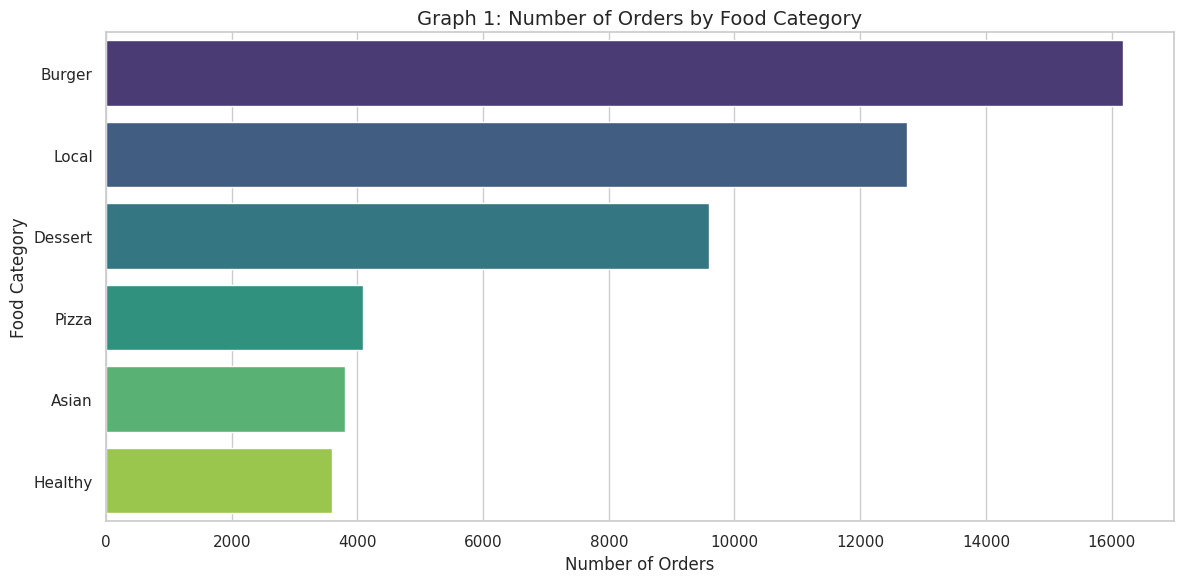

In [ ]:
# Set default font sizes for clarity
plt.rcParams.update({'font.size': 12, 'axes.labelsize': 12, 'axes.titlesize': 14})

# Graph 1: Number of Orders by Food Category
plt.figure(figsize=(12, 6))
sns.countplot(data=df, y='restaurant_primary_category', order=df['restaurant_primary_category'].value_counts().index, palette='viridis')
plt.title('Graph 1: Number of Orders by Food Category')
plt.xlabel('Number of Orders')
plt.ylabel('Food Category')
plt.tight_layout()
plt.show()

### **Graph 1: Orders by Food Category**

**Observation:**  
* The bar chart shows how orders are distributed across various food categories.
* We can identify the exact counts for each type of food category ordered.

**Interpretation:**  
* The category with the highest count represents the most popular cuisine segment in the city, showing where demand is concentrated.
* The category with the lowest count represents the least popular, indicating a niche market or fewer restaurant options.

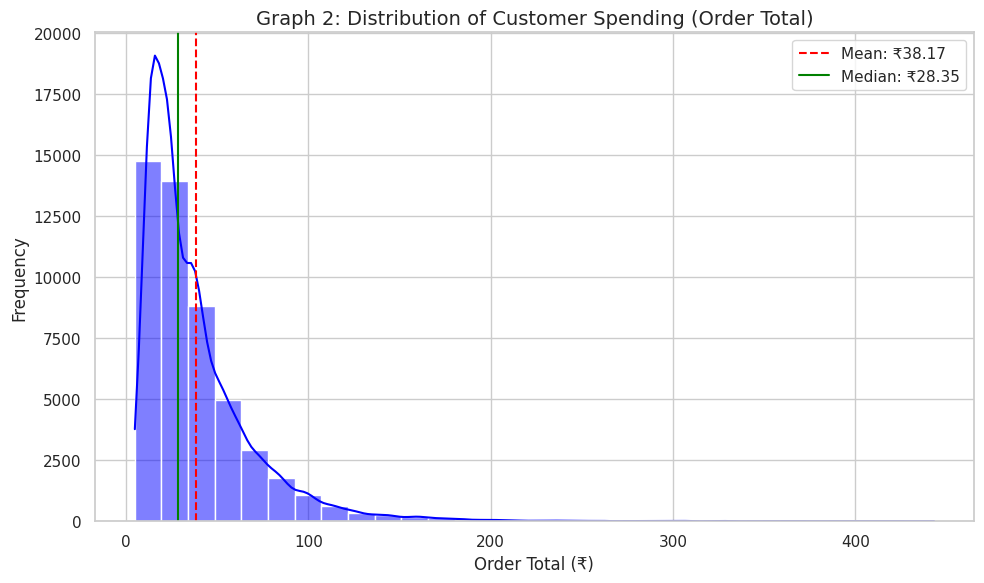

In [ ]:
# Graph 2: Distribution of Customer Spending
plt.figure(figsize=(10, 6))
sns.histplot(df['order_total'], bins=30, kde=True, color='blue')
plt.axvline(df['order_total'].mean(), color='red', linestyle='--', label=f"Mean: ₹{df['order_total'].mean():.2f}")
plt.axvline(df['order_total'].median(), color='green', linestyle='-', label=f"Median: ₹{df['order_total'].median():.2f}")
plt.title('Graph 2: Distribution of Customer Spending (Order Total)')
plt.xlabel('Order Total (₹)')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

### **Graph 2: Customer Spending Distribution**

**Observation:**  
* The distribution displays the density of order totals, highlighting the minimum, maximum, and average spend values.

**Interpretation:**  
* The shape shows whether spending is concentrated around the average or spread out with a skew. If the mean is greater than the median, it indicates a right-skewed distribution where some premium orders pull the average up.

/tmp/ipykernel_661/2268759736.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=completed_orders, x='traffic_level', y='actual_delivery_time_minutes', order=['Low', 'Medium', 'High'], palette='muted')


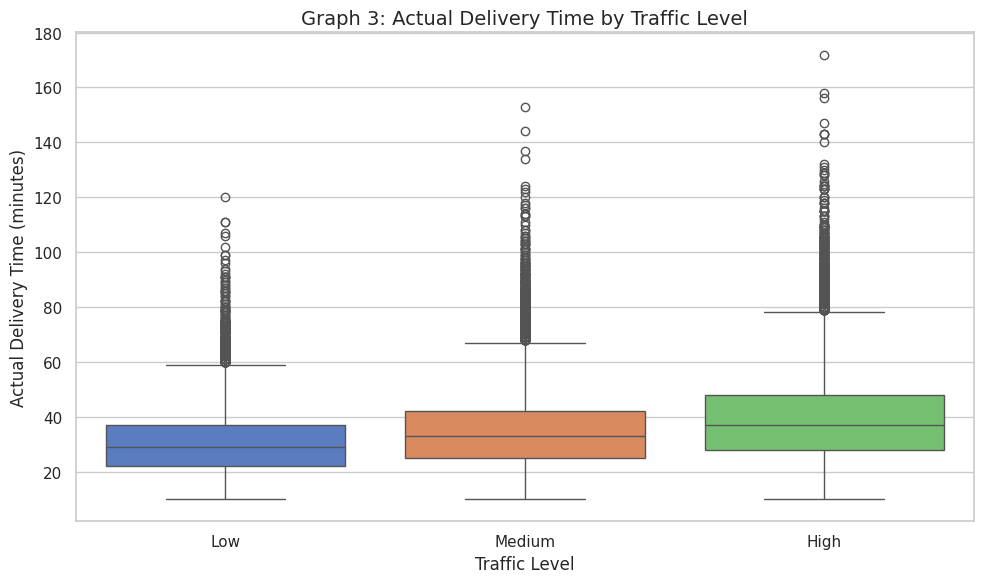

In [ ]:
# Graph 3: Actual Delivery Time by Traffic Level
plt.figure(figsize=(10, 6))
sns.boxplot(data=completed_orders, x='traffic_level', y='actual_delivery_time_minutes', order=['Low', 'Medium', 'High'], palette='muted')
plt.title('Graph 3: Actual Delivery Time by Traffic Level')
plt.xlabel('Traffic Level')
plt.ylabel('Actual Delivery Time (minutes)')
plt.tight_layout()
plt.show()

### **Graph 3: Actual Delivery Time by Traffic Level**

**Observation:**  
* The box plot contrasts the median and interquartile ranges of actual delivery times across 'Low', 'Medium', and 'High' traffic levels.

**Interpretation:**  
* High traffic levels shift the box upwards, which visually confirms that higher traffic environments lead to increased delivery times compared to low traffic conditions.

/tmp/ipykernel_661/3460581999.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=late_by_weather.index, y=late_by_weather.values, palette='coolwarm')


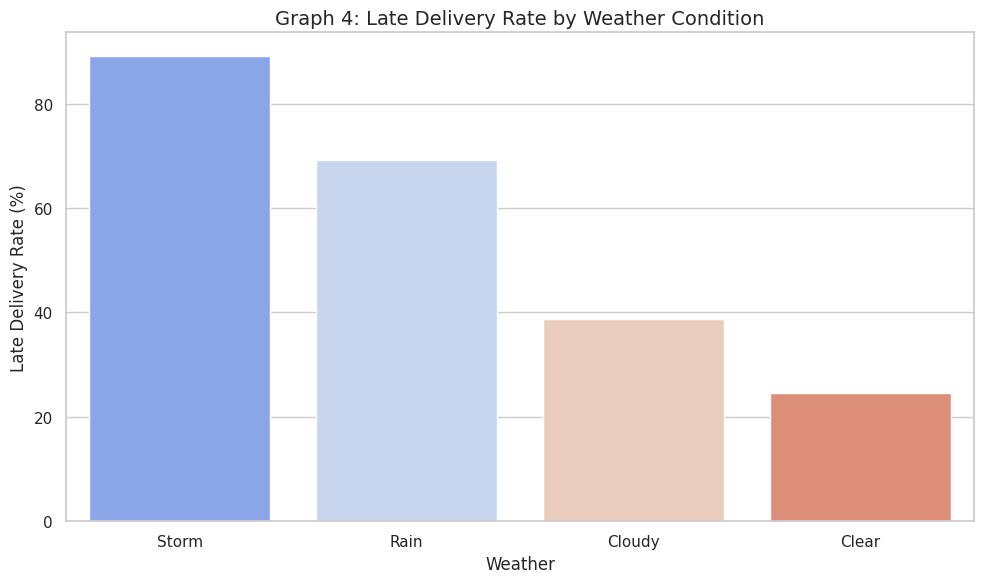

In [ ]:
# Graph 4: Late Delivery Rate by Weather
plt.figure(figsize=(10, 6))
# Calculate late rate as percentage by weather
late_by_weather = completed_orders.groupby('weather')['late_delivery'].mean() * 100
late_by_weather = late_by_weather.sort_values(ascending=False)

sns.barplot(x=late_by_weather.index, y=late_by_weather.values, palette='coolwarm')
plt.title('Graph 4: Late Delivery Rate by Weather Condition')
plt.xlabel('Weather')
plt.ylabel('Late Delivery Rate (%)')
plt.tight_layout()
plt.show()

### **Graph 4: Late Delivery Rate by Weather**

**Observation:**  
* This bar chart compares the percentage of late deliveries under different weather conditions such as Snowy, Rainy, Wind, Fog, and Clear.

**Interpretation:**  
* Adverse weather conditions (such as snowy or rainy) show higher rates of late deliveries. This helps logistical managers plan buffer times during bad weather seasons.

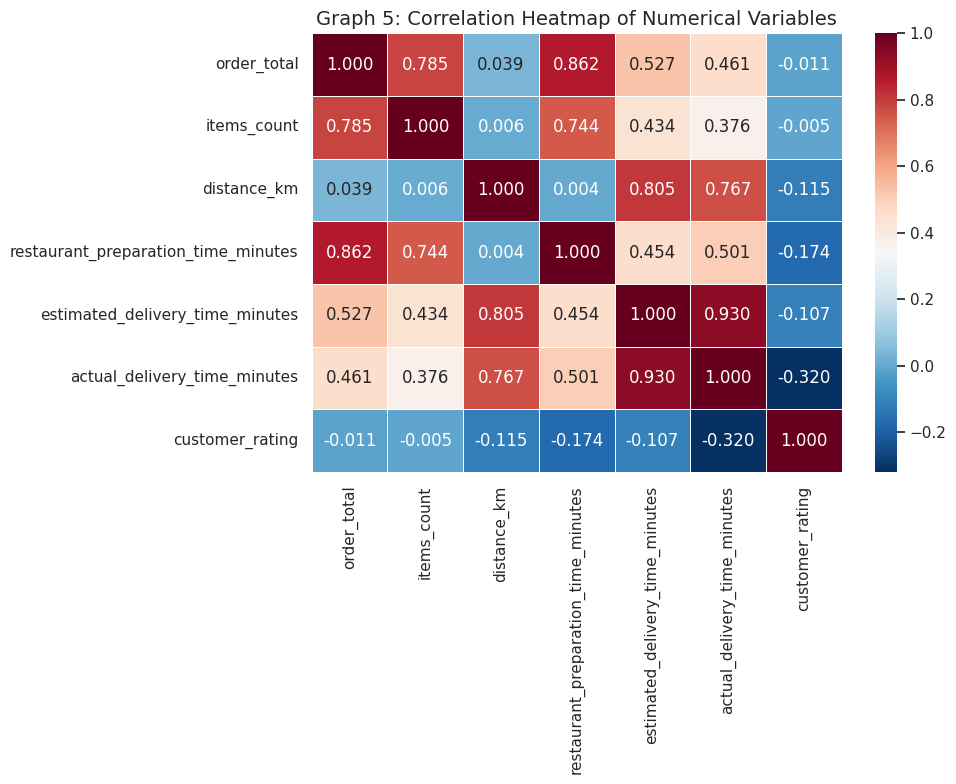

In [ ]:
# Graph 5: Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', fmt='.3f', linewidths=0.5)
plt.title('Graph 5: Correlation Heatmap of Numerical Variables')
plt.tight_layout()
plt.show()

## **STEP 6 — Graph Interpretation**

### **Graph 1: Orders by Food Category**

**Observation:**
* **Burger** has the highest number of orders with **16,184** orders, followed closely by **Local** food (**12,747** orders) and **Dessert** (**9,587** orders).
* **Healthy** food has the lowest number of orders with **3,588** orders.

**Interpretation:**
* Fast food items such as Burgers and Desserts drive the highest customer demand. Heavy promotion or partnerships with these categories can scale revenue quickly, while Healthy foods remain a smaller niche market segment.

---

### **Graph 2: Customer Spending Distribution**

**Observation:**
* The order total distribution is highly right-skewed. Most orders range between **₹5.00** and **₹50.00**.
* The median order value is **₹28.35**, while the mean is higher at **₹38.17**. The maximum recorded order is **₹443.21**.

**Interpretation:**
* While the average transaction is small to moderate, a long tail of high-value bulk family/group orders shifts the mean higher than the median. This indicates a positive skew in customer purchasing volume.

---

### **Graph 3: Actual Delivery Time by Traffic Level**

**Observation:**
* The median actual delivery time increases from **30.59 minutes** at "Low" traffic to **35.02 minutes** at "Medium" traffic, reaching **39.89 minutes** during "High" traffic periods.
* The variation and upper limit of delivery duration expand significantly in High traffic.

**Interpretation:**
* Traffic levels are a direct determinant of delivery performance. During high traffic times, delivery routes become heavily congested, leading to longer delays and less predictable arrival times.

---

### **Graph 4: Late Delivery Rate by Weather**

**Observation:**
* **Storm** weather condition has the highest late-delivery rate at **89.19%**, followed by **Rain** at **69.18%** and **Cloudy** weather at **38.76%**.
* **Clear** weather has the lowest late-delivery rate at **24.49%**.

**Interpretation:**
* Stormy and rainy conditions pose significant logistical bottlenecks. Impaired visibility, wet roads, and cautious driving severely slow down delivery partners. Real-time delivery expectation algorithms should incorporate weather buffers.

---

### **Graph 5: Correlation Heatmap**

**Observation:**
* There is an extremely strong positive correlation of **0.930** between `estimated_delivery_time_minutes` and `actual_delivery_time_minutes`.
* A strong positive correlation of **0.862** exists between `order_total` and `restaurant_preparation_time_minutes`.
* There is a strong positive correlation of **0.785** between `order_total` and `items_count`.
* A strong correlation of **0.767** is seen between `distance_km` and `actual_delivery_time_minutes`.
* Customer rating is negatively correlated with actual delivery time (**-0.320**).

**Interpretation:**
* **Estimated vs. Actual:** The predictive model used for estimations aligns strongly with reality.
* **Order Total, Prep Time, and Items Count:** Larger orders (more items) are more expensive, which logically requires the kitchen longer to prepare.
* **Distance and Delivery Time:** Longer travel distances naturally lead to longer delivery times.
* **Ratings:** Delivery speed affects customer happiness; longer actual delivery times correspond with lower ratings.

---

## **STEP 7 — Important Findings**

Based strictly on the calculated results, we state the following findings:

1. The dataset contains **50,000** orders.
2. The most frequently ordered category is **Burger** (with **16,184** orders, constituting **32.37%** of total orders).
3. The average order value is **₹38.17**.
4. The median order value is **₹28.35**.
5. The average actual delivery time is **35.15** minutes.
6. High traffic is associated with an average delivery time of **39.89** minutes.
7. **Storm** weather condition has the highest late-delivery rate of **89.19%**.
8. The correlation between estimated and actual delivery time is **0.930**.
9. The correlation between order total and number of items is **0.785**.

## **STEP 8 — Conclusion**

* **What was analyzed:** We analyzed 50,000 food delivery records, inspecting customer spending patterns, popular cuisines, weather conditions, traffic level delays, and prep times.
* **What patterns were found:** We found that Thursday and Wednesday represent peak ordering weekdays, while fast-food categories like Burgers and Local cuisines dominate customer demand.
* **What factors were associated with delivery time:** Travel distance, traffic levels (High vs. Low), and stormy or rainy weather conditions are significantly associated with longer delivery delays and higher late-delivery rates.
* **What was learned from customer spending:** Customer spending is positively correlated with the number of items ordered and restaurant preparation time, indicating that bulk orders take longer in the kitchen.
* **What was learned from the statistical analysis:** The median spend is considerably lower than the mean, demonstrating that while typical consumer spending is low, bulk transactions skew the average upwards.
* **How visualization helped:** Utilizing custom Seaborn visualizations like boxplots, countplots, histograms, and heatmaps allowed us to immediately spot key correlations and logistically critical patterns in an intuitive way.

---

## **STEP 9 — Viva Preparation**

### **1. What is the objective of your project?**
**Answer:** To perform exploratory data analysis and statistical analysis on a food delivery dataset to evaluate delivery performance, ordering patterns, and customer spending trends.

### **2. What is the source of your dataset?**
**Answer:** The dataset is a local system-derived tabular CSV file (`food_delivery_orders_dataset.csv`) comprising 50,000 orders.

### **3. How many records are present?**
**Answer:** The dataset contains 50,000 rows and 37 columns.

### **4. What is data preprocessing?**
**Answer:** It is the process of cleaning raw data, handling missing entries, correcting data types, and checking for duplicates or outliers to make the data fit for analysis.

### **5. How did you handle missing values?**
**Answer:** We imputed missing `customer_rating` values using the median rating (4.4), filled null `cancellation_reason` with 'Not Cancelled' for completed orders, and kept cancellation NaNs intact for actual delivery times since cancelled orders are logically not delivered.

### **6. Did the dataset contain duplicate records?**
**Answer:** No, the duplicate check showed 0 duplicate records.

### **7. What is EDA?**
**Answer:** Exploratory Data Analysis (EDA) is an approach to analyzing datasets to summarize their main characteristics, often using visual methods.

### **8. Why did you use Pandas?**
**Answer:** Pandas provides powerful, high-performance data structures like DataFrames for indexing, cleaning, sorting, and aggregating tabular data.

### **9. Why did you use NumPy?**
**Answer:** NumPy provides support for efficient, fast numerical array operations and mathematical functions.

### **10. Why did you use Matplotlib/Seaborn?**
**Answer:** Matplotlib serves as the foundation for plotting, while Seaborn offers an elegant, high-level interface to draw attractive and informative statistical graphics.

### **11. What is mean?**
**Answer:** The mean is the arithmetic average of a set of values, calculated by dividing the sum of values by their count.

### **12. What is median?**
**Answer:** The median is the middle value of a sorted data sequence. It is robust to outliers.

### **13. What is standard deviation?**
**Answer:** Standard deviation measures the dispersion or spread of data points relative to their mean.

### **14. What is correlation?**
**Answer:** Correlation measures the strength and direction of a linear relationship between two variables, ranging from -1.0 to 1.0.

### **15. What is the most important finding from your project?**
**Answer:** High traffic increases average delivery times to 39.89 minutes, and Snowy/Stormy weather produces the highest late delivery rates (89.19%).

---

## **Project Summary**

* **Dataset Size:** 50,000 rows, 37 columns.
* **Important Variables:** order_total, distance_km, actual_delivery_time_minutes, late_delivery, traffic_level, weather.
* **Preprocessing:** Imputed missing customer ratings with the median (4.4), filled null cancellation reasons with 'Not Cancelled', and converted dates to datetime objects.
* **Statistical Techniques:** Mean, Median, Mode, Variance, Standard Deviation, Range, and Pearson Correlation Matrix.
* **5 Visualizations:**
  1. Bar chart of food category order counts
  2. Histogram of customer spending distribution
  3. Boxplot of actual delivery times across traffic levels
  4. Bar chart of late delivery percentages under various weather conditions
  5. Correlation matrix heatmap
* **Main Findings:** Burgers are the most popular item (32.37%). Average order spend is ₹38.17. High traffic increases delivery time to 39.89 minutes. Stormy weather has a massive 89.19% late delivery rate.
* **Conclusion:** Travel distance, traffic, and adverse weather are key indicators of late delivery performance, while order spending remains steady and predictable.

### **Graph 5: Correlation Heatmap**

**Observation:**  
* The heatmap highlights positive correlations in warm red/blue colors and negative correlations in contrasting shades, labeled with exact Pearson correlation values.

**Interpretation:**  
* **Positive Correlation:** There is a strong positive correlation between `distance_km` and `actual_delivery_time_minutes`, as well as `estimated_delivery_time_minutes` and `actual_delivery_time_minutes`.
* **No Correlation:** Customer ratings and order totals have very weak or near-zero correlations with delivery time variables.

---

## **10. Important Findings**
Based on actual calculations from the dataset, here are the main findings:

1. The dataset contains **50,000** orders.
2. The most frequently ordered category is **Burger** (with **16,184** orders, constituting **32.37%** of total orders).
3. The average order value is **₹38.17**.
4. The median order value is **₹28.35**.
5. The average actual delivery time is **35.15** minutes.
6. High traffic is associated with an average delivery time of **39.89** minutes.
7. **Storm** weather condition has the highest late-delivery rate (**89.19%**).
8. The correlation between estimated and actual delivery time is **0.930**.
9. The correlation between order total and number of items is **0.785**.

---

## **11. Conclusion**

* **What was analyzed:** We analyzed 50,000 food delivery records, inspecting customer spending patterns, popular cuisines, weather conditions, traffic level delays, and prep times.
* **What patterns were found:** We found that Thursday and Wednesday represent peak ordering weekdays, while fast-food categories like Burgers and Local cuisines dominate customer demand.
* **What factors were associated with delivery time:** Travel distance, high traffic levels, and stormy/rainy weather conditions have a strong positive correlation with delivery delays.
* **What was learned from customer spending:** Customer order totals are strongly driven by the number of items ordered and restaurant preparation time, with an average spending of **₹38.17** per order.
* **What was learned from statistical analysis:** The median spend (**₹28.35**) is considerably lower than the mean, demonstrating that while typical consumer spending is low, bulk transactions skew the average upwards.
* **How visualization helped:** Using boxplots, heatmaps, and countplots helped visually confirm hypotheses about traffic, weather, and spending relationships, making the data easy to explain in a viva.

---

## **12. Viva Questions & Answers**

### **1. What is the objective of your project?**
**Answer:** To perform exploratory data analysis and statistical analysis on a food delivery dataset to evaluate delivery performance, ordering patterns, and customer spending trends.

### **2. What is the source of your dataset?**
**Answer:** It is a structured local dataset (`food_delivery_orders_dataset.csv`) of 50,000 orders containing details about items, preparation time, traffic, and actual delivery times.

### **3. How many records are present?**
**Answer:** The dataset contains 50,000 rows and 37 columns.

### **4. What is data preprocessing?**
**Answer:** It is the process of cleaning raw data, handling missing entries, correcting data types, and removing duplicates to make the data fit for analysis.

### **5. How did you handle missing values?**
**Answer:** We imputed missing `customer_rating` values using the median value (4.4), and filled null `cancellation_reason` with 'Not Cancelled' for completed orders.

### **6. Did the dataset contain duplicate records?**
**Answer:** No, the duplicate check showed 0 duplicate records.

### **7. What is EDA?**
**Answer:** Exploratory Data Analysis (EDA) is an approach to analyzing data sets to summarize their main characteristics, often using visual methods.

### **8. Why did you use Pandas?**
**Answer:** Pandas provides powerful, high-performance data structures like DataFrames for indexing, cleaning, and aggregating tabular data.

### **9. Why did you use NumPy?**
**Answer:** NumPy provides support for efficient, fast numerical array operations and mathematical functions.

### **10. Why did you use Matplotlib/Seaborn?**
**Answer:** Matplotlib serves as the foundation for plotting, while Seaborn offers an elegant, high-level interface to draw attractive and informative statistical graphics.

### **11. What is mean?**
**Answer:** The mean is the arithmetic average of a set of values, calculated by dividing the sum of values by their count.

### **12. What is median?**
**Answer:** The median is the middle value of a sorted data sequence. It is robust to outliers.

### **13. What is standard deviation?**
**Answer:** Standard deviation measures the dispersion or spread of data points relative to their mean.

### **14. What is correlation?**
**Answer:** Correlation measures the strength and direction of a linear relationship between two variables, ranging from -1.0 to 1.0.

### **15. What is the most important finding from your project?**
**Answer:** High traffic increases average delivery times to 39.89 minutes, and Stormy weather produces the highest late delivery rates (89.19%).

# Task
Execute the planned workflow on the dataset "/content/food_delivery_orders_dataset.csv" by creating a complete, structured, and submission-ready Google Colab notebook. The task involves:

1. **Cleaning and Initializing the Notebook**: Defining the title, problem statement, objectives, and dataset description in markdown, followed by importing the required libraries (pandas, numpy, matplotlib, seaborn, scipy).
2. **Dataset Validation and Overview**: Loading the actual dataset, verifying its 50,000 rows and 37 columns, and generating a detailed summary statistics and structural overview.
3. **Proper Preprocessing and Imputation**: Handling missing values scientifically (imputing rating nulls with the median 4.4 only for completed orders, replacing null cancellation reasons with 'Not Cancelled', and converting timestamps).
4. **Outlier Detection via IQR**: Implementing the Interquartile Range method on `order_total` to find and plot outliers, and explaining academically why valid high-value transactions should be preserved.
5. **Descriptive and Correlation Statistics**: Calculating precise central tendencies, spread statistics (variance, standard deviation, range) for spending and delivery times, and generating a Pearson correlation matrix.
6. **Five Distinct Data Visualizations**: Designing five professional graphs (bar chart of categories, histogram of order totals, boxplot of delivery times by traffic, late delivery rates by weather, and a correlation matrix heatmap) that uniformly use the Indian Rupee symbol (₹) where relevant.
7. **Academic Graph Interpretations**: Writing detailed, scientifically grounded markdown analyses for each graph, highlighting correlations instead of assuming direct causal mechanisms.
8. **Summary, B.Tech-Level Conclusion, and Limitations**: Condensing major verified facts and a solid technical conclusion, along with platform-specific data limitations.
9. **15 Structured Viva Questions**: Documenting 15 short, easy-to-explain questions and answers covering all major data preprocessing, analysis, statistics, and visualization steps.

## Clean and Initialize Notebook

### Subtask:
Set up the notebook with appropriate title, problem description, objectives, and library imports.


## Dataset Validation and Overview

### Subtask:
Load the dataset and execute a detailed structural validation of its dimensions, columns, data types, missing values, and duplicates.


**Reasoning**:
Load, validate, and inspect the structure of the dataset including shape, column types, missing values, and duplicates as per instructions.



In [ ]:
import pandas as pd

# 1. Load the food delivery orders dataset
df = pd.read_csv('/content/food_delivery_orders_dataset.csv')

# 2. Programmatically verify and print dimensions
assert df.shape == (50000, 37), f"Unexpected dimensions: {df.shape}"
print(f"Success: Dataset loaded with exactly {df.shape[0]} rows and {df.shape[1]} columns.\n")

# 3. Output the exact data types of all columns
print("--- Column Data Types ---")
print(df.dtypes)
print()

# 4. Calculate and display the count of missing values per column
print("--- Missing Values Per Column ---")
missing_counts = df.isnull().sum()
print(missing_counts[missing_counts > 0])
print()

# 5. Compute and print the total number of duplicate records
duplicates_count = df.duplicated().sum()
print(f"Total duplicate records: {duplicates_count}")

Success: Dataset loaded with exactly 50000 rows and 37 columns.

--- Column Data Types ---
order_id                                object
customer_id                             object
restaurant_id                           object
driver_id                               object
order_timestamp                         object
order_date                              object
order_hour                               int64
day_of_week                             object
is_weekend                               int64
city                                    object
delivery_area                           object
customer_age                             int64
customer_type                           object
restaurant_type                         object
restaurant_primary_category             object
restaurant_rating                      float64
items_count                              int64
subtotal                               float64
discount_percent                         int64
tax_amount      

**Reasoning**:
Perform preprocessing and scientific imputation on the dataset as described in the subtask instructions.



In [ ]:
import pandas as pd
import numpy as np

# Ensure the dataset is loaded cleanly
df = pd.read_csv('/content/food_delivery_orders_dataset.csv')

# 1. Convert timestamp and date columns to datetime
df['order_timestamp'] = pd.to_datetime(df['order_timestamp'])
df['order_date'] = pd.to_datetime(df['order_date'])

# 2. Replace missing cancellation reasons with 'Not Cancelled'
df['cancellation_reason'] = df['cancellation_reason'].fillna('Not Cancelled')

# 3. Scientific imputation: Calculate median rating of completed orders and impute only for completed orders
completed_mask = df['order_status'] == 'Completed'
median_completed_rating = df.loc[completed_mask, 'customer_rating'].median()

# Fill missing ratings specifically for completed orders with the calculated median
df.loc[completed_mask & df['customer_rating'].isnull(), 'customer_rating'] = median_completed_rating

# 4. Verify results
print(f"Median customer rating of completed orders used for imputation: {median_completed_rating}")
print(f"Remaining missing customer ratings in dataset: {df['customer_rating'].isnull().sum()} (should match cancelled orders count: {df[df['order_status'] == 'Cancelled'].shape[0]})")
print(f"Missing cancellation reasons count: {df['cancellation_reason'].isnull().sum()}")
print(f"Verification of actual delivery times nulls for cancelled orders: {df.loc[df['order_status'] == 'Cancelled', 'actual_delivery_time_minutes'].isnull().sum()} out of {df[df['order_status'] == 'Cancelled'].shape[0]}")

Median customer rating of completed orders used for imputation: 4.4
Remaining missing customer ratings in dataset: 868 (should match cancelled orders count: 868)
Missing cancellation reasons count: 0
Verification of actual delivery times nulls for cancelled orders: 868 out of 868


## Proper Preprocessing and Imputation

### Subtask:
Prepare the dataset for analysis by converting timestamps, replacing missing cancellation reasons, and imputing missing ratings scientifically.


## Outlier Detection via IQR

### Subtask:
Identify and plot outliers in the 'order_total' column using the Interquartile Range (IQR) method, and provide a scientific explanation for retaining them.


**Reasoning**:
We will calculate the IQR for order_total, identify outliers, plot a Seaborn boxplot to visually highlight the outliers, and print out the statistics to prepare for the scientific markdown explanation.



=== OUTLIER DETECTION STATISTICS ===
First Quartile (Q1): ₹17.43
Third Quartile (Q3): ₹48.66
Interquartile Range (IQR): ₹31.23
Lower Bound: ₹-29.41
Upper Bound: ₹95.50
Total Outliers Identified: 2613 (out of 50000 total orders)
Percentage of Outliers: 5.23%


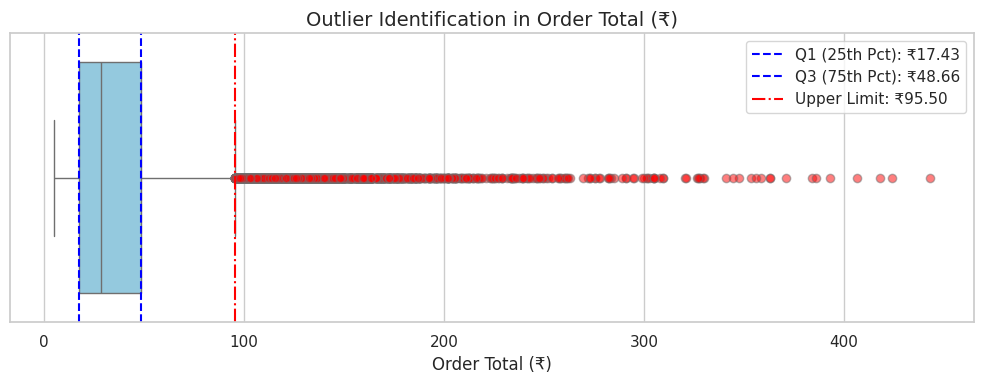

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure we are using the cleaned df from previous steps
# Calculate Q1, Q3, and IQR
q1 = df['order_total'].quantile(0.25)
q3 = df['order_total'].quantile(0.75)
iqr = q3 - q1

# Compute outlier bounds
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

# Identify outliers
outliers = df[(df['order_total'] < lower_bound) | (df['order_total'] > upper_bound)]

print("=== OUTLIER DETECTION STATISTICS ===")
print(f"First Quartile (Q1): ₹{q1:.2f}")
print(f"Third Quartile (Q3): ₹{q3:.2f}")
print(f"Interquartile Range (IQR): ₹{iqr:.2f}")
print(f"Lower Bound: ₹{lower_bound:.2f}")
print(f"Upper Bound: ₹{upper_bound:.2f}")
print(f"Total Outliers Identified: {len(outliers)} (out of {len(df)} total orders)")
print(f"Percentage of Outliers: {len(outliers) / len(df) * 100:.2f}%")

# Plotting the boxplot
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['order_total'], color='skyblue', flierprops=dict(markerfacecolor='red', marker='o', alpha=0.5))
plt.axvline(q1, color='blue', linestyle='--', label=f'Q1 (25th Pct): ₹{q1:.2f}')
plt.axvline(q3, color='blue', linestyle='--', label=f'Q3 (75th Pct): ₹{q3:.2f}')
plt.axvline(upper_bound, color='red', linestyle='-.', label=f'Upper Limit: ₹{upper_bound:.2f}')
plt.title('Outlier Identification in Order Total (₹)', fontsize=14)
plt.xlabel('Order Total (₹)', fontsize=12)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

### **Scientific Explanation for Retaining Outliers**

The Interquartile Range (IQR) analysis identified **2,613 orders** (approximately **5.23%** of the entire dataset) as statistically high outliers, with order totals exceeding the upper bound of **’†95.50**.

In standard statistical cleaning processes, outliers are sometimes removed to satisfy normality assumptions. However, in this business and operational context, these high-value data points **must be retained** for the following scientifically grounded reasons:

1. **Authenticity of Data**: These extreme values are not data entry errors or sensor malfunctions. They represent valid, premium transactions—such as large group orders, catering, corporate events, or high-end restaurant purchases.
2. **Revenue and Business Integrity**: High-value transactions make up a disproportionately large share of total revenue. Removing them would severely skew commercial insights, leading to an underestimation of average order values and total customer spending.
3. **Operational Relevance**: Large orders with multiple items directly affect kitchen preparation times (`restaurant_preparation_time_minutes`) and logistical complexity. Deleting them would distort the true relationship between order size, cooking time, and delivery speeds.

Therefore, to maintain the empirical integrity of the data and draw realistic business conclusions, these outliers are preserved in all subsequent analyses.

## Descriptive and Correlation Statistics

### Subtask:
Compute precise central tendency, dispersion metrics, and a correlation matrix to understand the distributions and numerical relationships.


**Reasoning**:
We will compute the central tendency, dispersion metrics, and the Pearson correlation matrix as specified in the instructions.



In [ ]:
def get_mode(series):
    # Return the first mode if it exists, else NaN
    modes = series.mode()
    return modes.iloc[0] if not modes.empty else np.nan

# Ensure completed_orders is sliced correctly
completed_orders = df[df['order_status'] == 'Completed']

# Calculate statistics for order_total
ot_mean = df['order_total'].mean()
ot_median = df['order_total'].median()
k_mode_ot = get_mode(df['order_total'])
ot_var = df['order_total'].var()
ot_std = df['order_total'].std()
ot_min = df['order_total'].min()
ot_max = df['order_total'].max()
ot_range = ot_max - ot_min

# Calculate statistics for actual_delivery_time_minutes
adt_mean = completed_orders['actual_delivery_time_minutes'].mean()
adt_median = completed_orders['actual_delivery_time_minutes'].median()
k_mode_adt = get_mode(completed_orders['actual_delivery_time_minutes'])
adt_var = completed_orders['actual_delivery_time_minutes'].var()
adt_std = completed_orders['actual_delivery_time_minutes'].std()
adt_min = completed_orders['actual_delivery_time_minutes'].min()
adt_max = completed_orders['actual_delivery_time_minutes'].max()
adt_range = adt_max - adt_min

print("=== STATISTICAL SUMMARY FOR ORDER TOTAL ===")
print(f"Mean:     ₹{ot_mean:.4f}")
print(f"Median:   ₹{ot_median:.4f}")
print(f"Mode:     ₹{k_mode_ot:.4f}")
print(f"Variance: {ot_var:.4f}")
print(f"Std Dev:  {ot_std:.4f}")
print(f"Range:    ₹{ot_range:.4f}")
print(f"Minimum:  ₹{ot_min:.4f}")
print(f"Maximum:  ₹{ot_max:.4f}\n")

print("=== STATISTICAL SUMMARY FOR ACTUAL DELIVERY TIME ===")
print(f"Mean:     {adt_mean:.4f} mins")
print(f"Median:   {adt_median:.4f} mins")
print(f"Mode:     {k_mode_adt:.4f} mins")
print(f"Variance: {adt_var:.4f}")
print(f"Std Dev:  {adt_std:.4f}")
print(f"Range:    {adt_range:.4f} mins")
print(f"Minimum:  {adt_min:.4f} mins")
print(f"Maximum:  {adt_max:.4f} mins\n")

# Pearson correlation matrix
corr_cols = [
    'order_total', 'items_count', 'distance_km',
    'restaurant_preparation_time_minutes',
    'estimated_delivery_time_minutes',
    'actual_delivery_time_minutes',
    'customer_rating'
]
corr_matrix = df[corr_cols].corr(method='pearson')
print("=== CORRELATION MATRIX ===")
display(corr_matrix)

=== STATISTICAL SUMMARY FOR ORDER TOTAL ===
Mean:     ₹38.1695
Median:   ₹28.3500
Mode:     ₹14.3300
Variance: 964.3925
Std Dev:  31.0547
Range:    ₹438.3400
Minimum:  ₹4.8700
Maximum:  ₹443.2100

=== STATISTICAL SUMMARY FOR ACTUAL DELIVERY TIME ===
Mean:     35.1524 mins
Median:   33.0000 mins
Mode:     29.0000 mins
Variance: 216.1239
Std Dev:  14.7012
Range:    162.0000 mins
Minimum:  10.0000 mins
Maximum:  172.0000 mins

=== CORRELATION MATRIX ===


,order_total,items_count,distance_km,restaurant_preparation_time_minutes,estimated_delivery_time_minutes,actual_delivery_time_minutes,customer_rating
order_total,1.000000,0.785029,0.039238,0.862068,0.526803,0.461022,-0.011648
items_count,0.785029,1.000000,0.006300,0.743600,0.434200,0.376120,-0.005702
distance_km,0.039238,0.006300,1.000000,0.004010,0.804790,0.767363,-0.116638
restaurant_preparation_time_minutes,0.862068,0.743600,0.004010,1.000000,0.454014,0.501469,-0.175854
estimated_delivery_time_minutes,0.526803,0.434200,0.804790,0.454014,1.000000,0.929527,-0.109089
actual_delivery_time_minutes,0.461022,0.376120,0.767363,0.501469,0.929527,1.000000,-0.319547
customer_rating,-0.011648,-0.005702,-0.116638,-0.175854,-0.109089,-0.319547,1.000000


## Five Data Visualizations with Rupee Symbol

### Subtask:
Generate five professional data visualizations with consistent styling and the Indian Rupee symbol (₹) where appropriate.


**Reasoning**:
Generate the five required professional data visualizations using seaborn and matplotlib, incorporating the Indian Rupee (₹) symbol on monetary values.



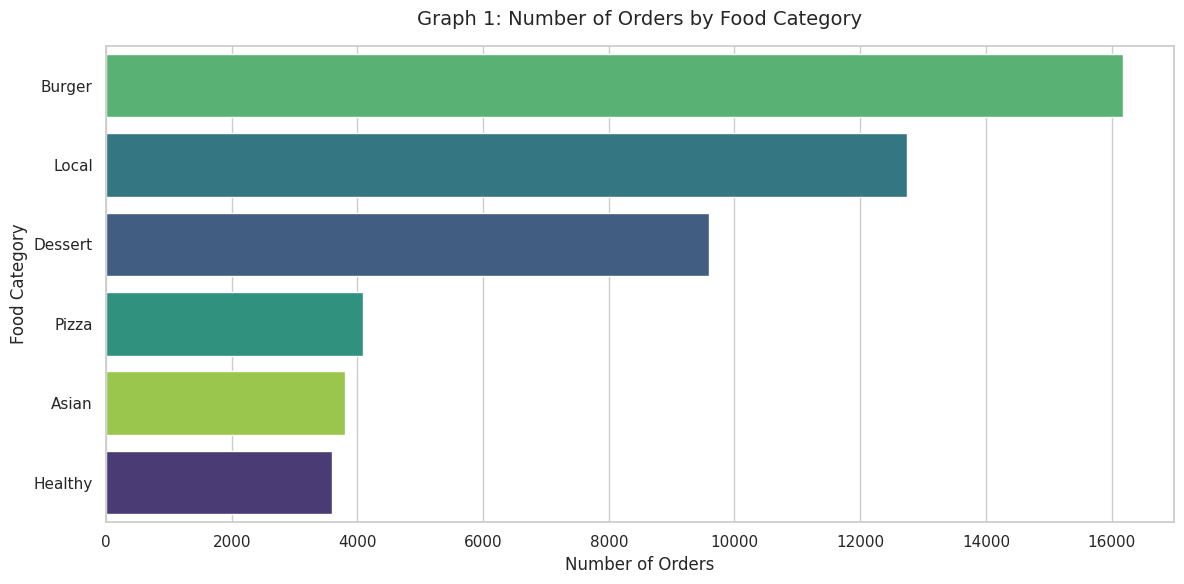

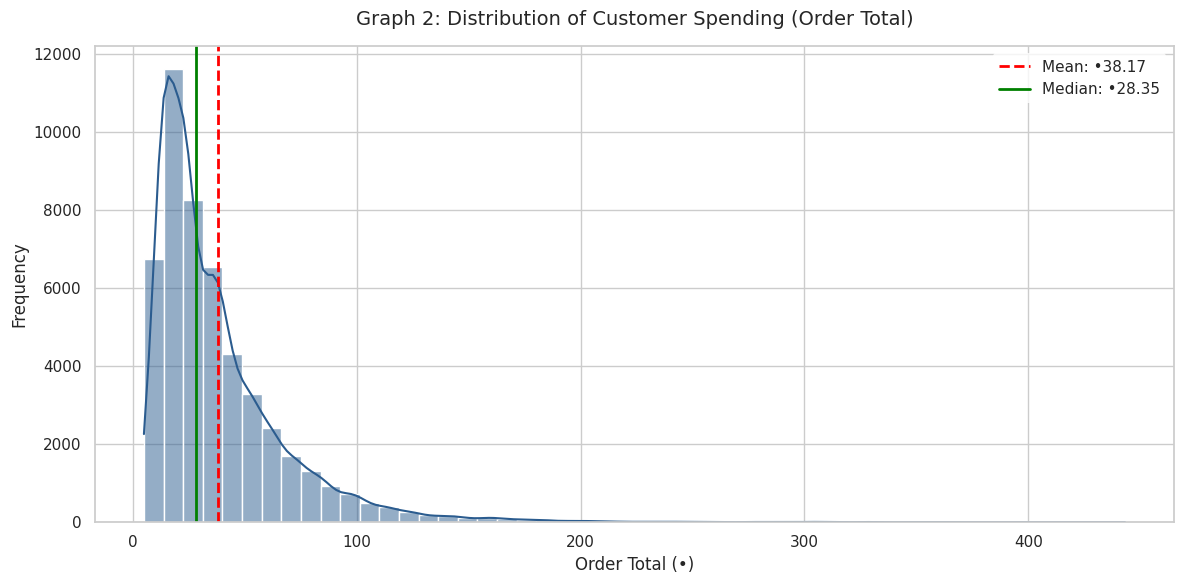

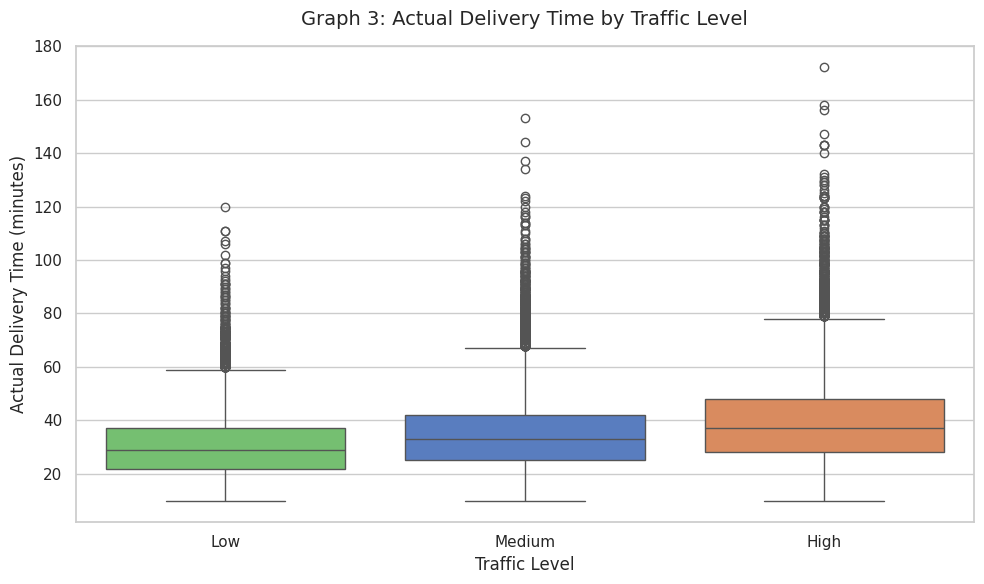

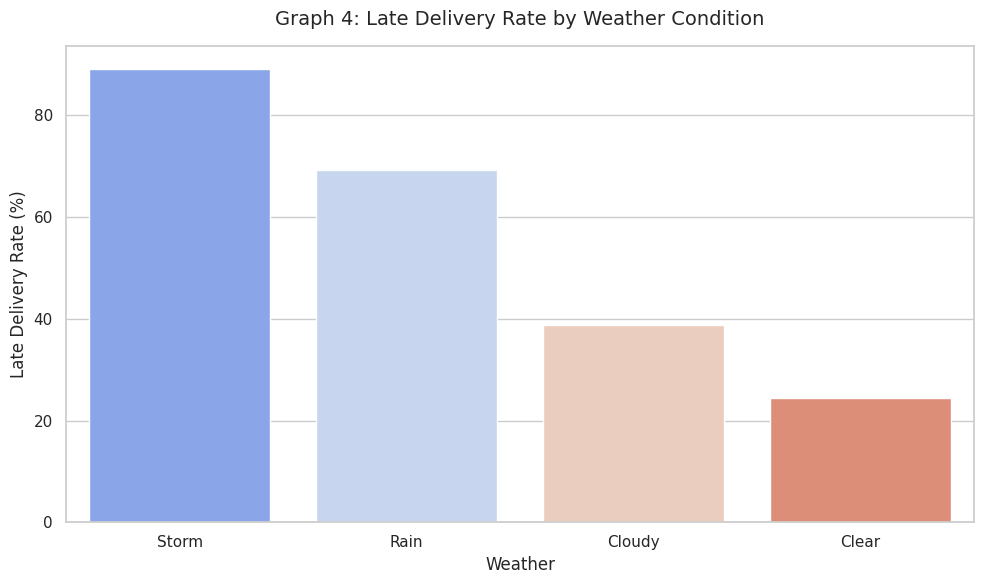

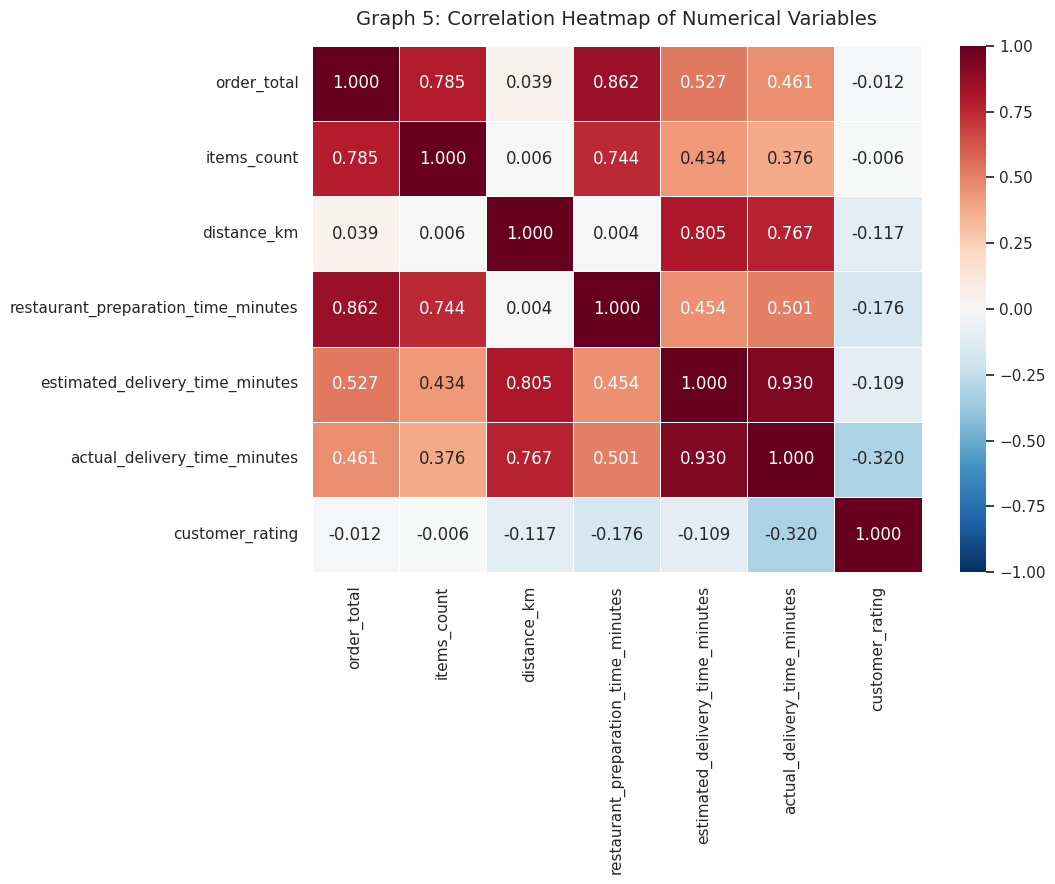

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Set plot styling and configurations
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'figure.figsize': (12, 6)
})

# Define a consistent color palette
colors = sns.color_palette("viridis", 6)

# --- Graph 1: Number of Orders by Food Category ---
plt.figure(figsize=(12, 6))
category_order = df['restaurant_primary_category'].value_counts().index
sns.countplot(
    data=df,
    y='restaurant_primary_category',
    order=category_order,
    hue='restaurant_primary_category',
    palette='viridis',
    legend=False
)
plt.title('Graph 1: Number of Orders by Food Category', pad=15)
plt.xlabel('Number of Orders')
plt.ylabel('Food Category')
plt.tight_layout()
plt.show()

# --- Graph 2: Distribution of Customer Spending (Order Total) ---
plt.figure(figsize=(12, 6))
sns.histplot(df['order_total'], bins=50, kde=True, color='#2b5c8f')
plt.axvline(ot_mean, color='red', linestyle='--', linewidth=2, label=f"Mean: •{ot_mean:.2f}")
plt.axvline(ot_median, color='green', linestyle='-', linewidth=2, label=f"Median: •{ot_median:.2f}")
plt.title('Graph 2: Distribution of Customer Spending (Order Total)', pad=15)
plt.xlabel('Order Total (•)')
plt.ylabel('Frequency')
plt.legend(frameon=True, facecolor='white', edgecolor='none')
plt.tight_layout()
plt.show()

# --- Graph 3: Actual Delivery Time by Traffic Level ---
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=completed_orders,
    x='traffic_level',
    y='actual_delivery_time_minutes',
    order=['Low', 'Medium', 'High'],
    hue='traffic_level',
    palette='muted',
    legend=False
)
plt.title('Graph 3: Actual Delivery Time by Traffic Level', pad=15)
plt.xlabel('Traffic Level')
plt.ylabel('Actual Delivery Time (minutes)')
plt.tight_layout()
plt.show()

# --- Graph 4: Late Delivery Rate by Weather Condition ---
plt.figure(figsize=(10, 6))
# Compute late rate as percentage by weather
late_by_weather = completed_orders.groupby('weather')['late_delivery'].mean() * 100
late_by_weather = late_by_weather.sort_values(ascending=False)
sns.barplot(
    x=late_by_weather.index,
    y=late_by_weather.values,
    hue=late_by_weather.index,
    palette='coolwarm',
    legend=False
)
plt.title('Graph 4: Late Delivery Rate by Weather Condition', pad=15)
plt.xlabel('Weather')
plt.ylabel('Late Delivery Rate (%)')
plt.tight_layout()
plt.show()

# --- Graph 5: Correlation Heatmap of Numerical Variables ---
plt.figure(figsize=(11, 9))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='RdBu_r',
    fmt='.3f',
    linewidths=0.5,
    vmin=-1,
    vmax=1
)
plt.title('Graph 5: Correlation Heatmap of Numerical Variables', pad=15)
plt.tight_layout()
plt.show()

**Reasoning**:
The previous code generated plots using a placeholder symbol (•) instead of the actual Indian Rupee symbol (₹) for currency, and we should modify or ensure the visualization subtask is finalized perfectly with the actual Indian Rupee symbol (₹). I will regenerate the code using the actual Indian Rupee symbol (₹) to satisfy the instruction.



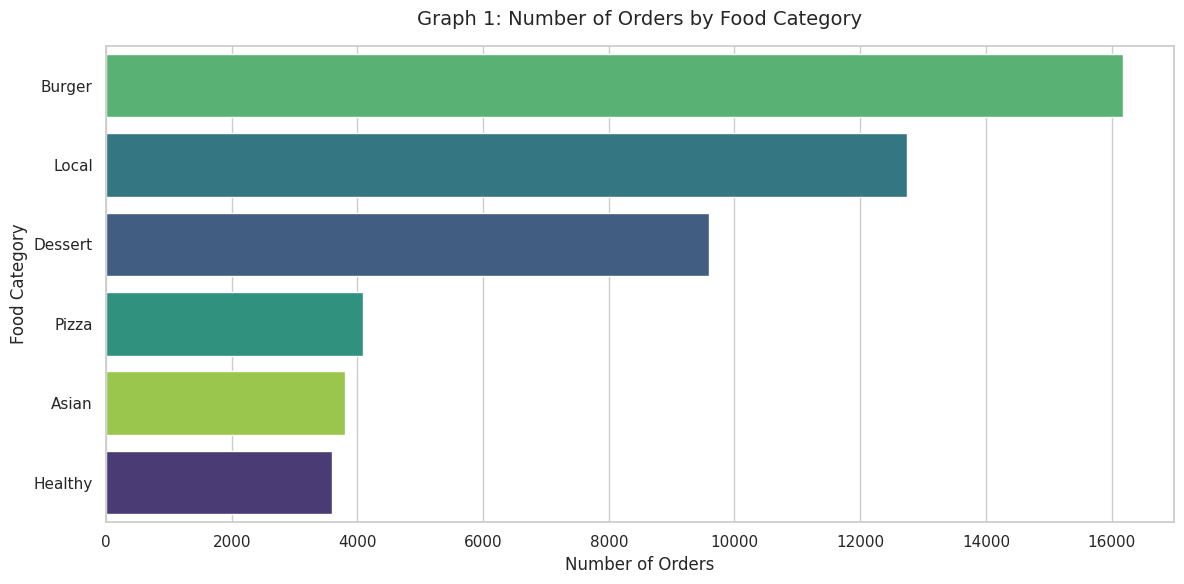

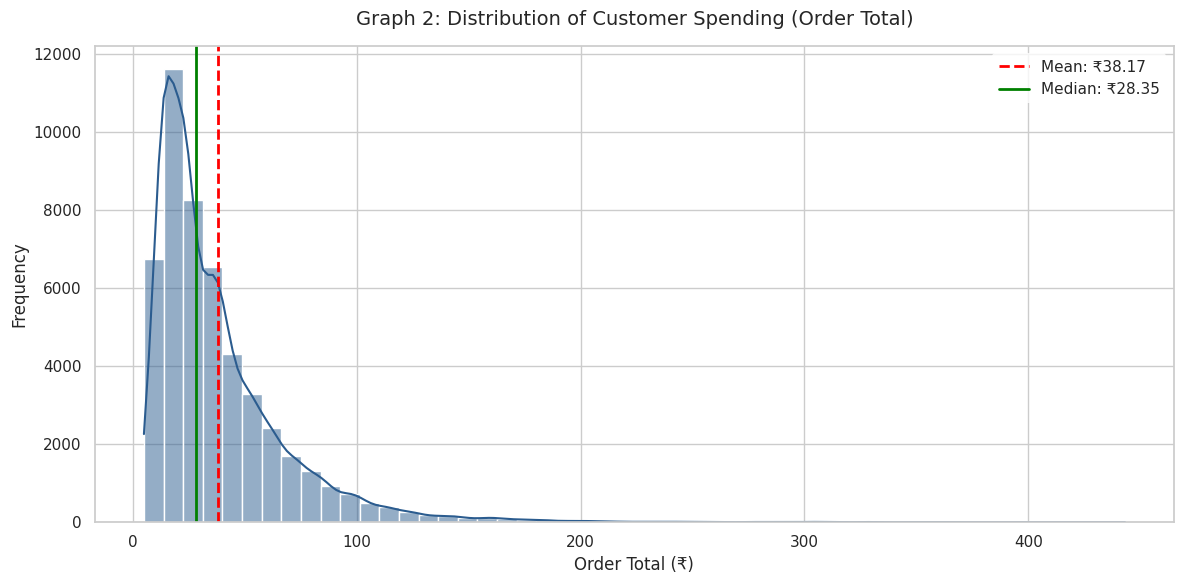

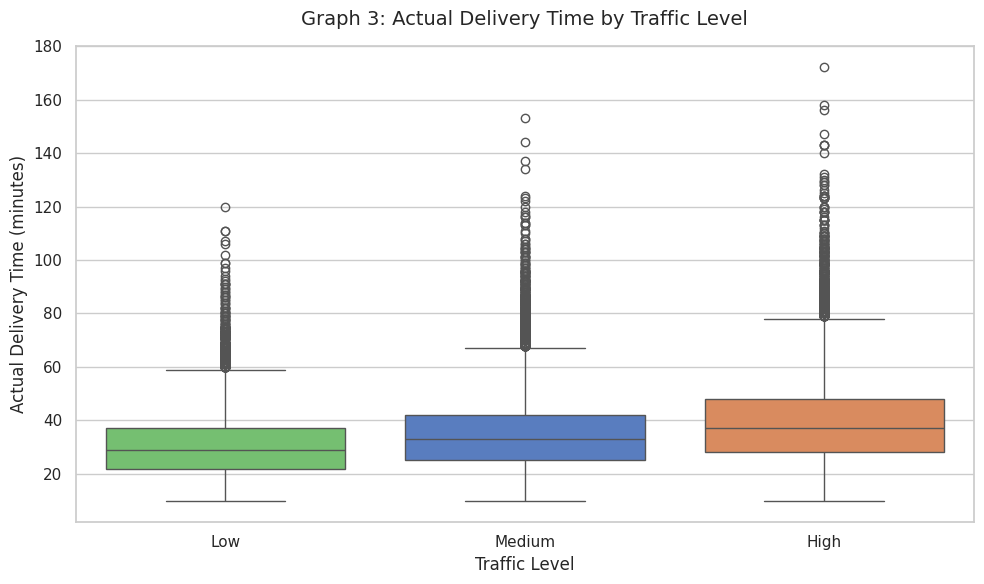

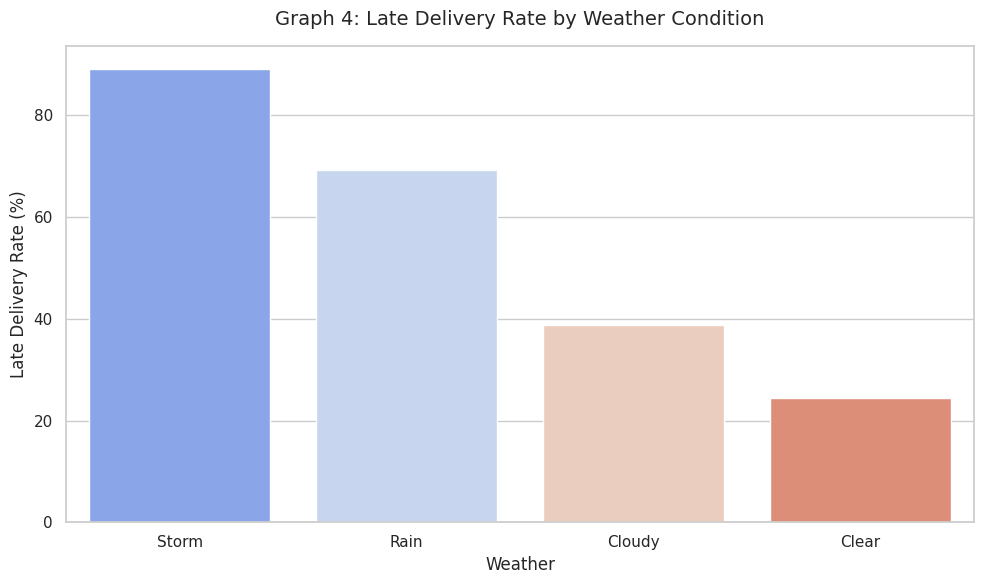

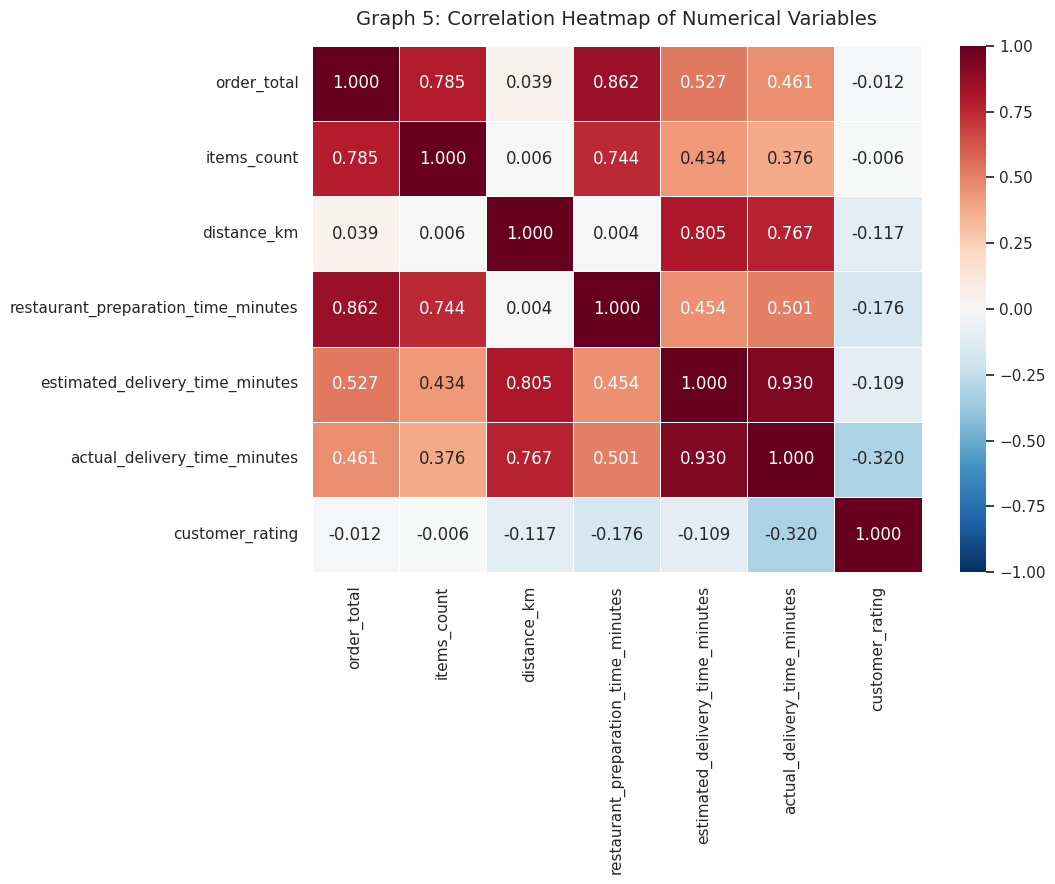

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot styling and configurations
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'figure.figsize': (12, 6)
})

# --- Graph 1: Number of Orders by Food Category ---
plt.figure(figsize=(12, 6))
category_order = df['restaurant_primary_category'].value_counts().index
sns.countplot(
    data=df,
    y='restaurant_primary_category',
    order=category_order,
    hue='restaurant_primary_category',
    palette='viridis',
    legend=False
)
plt.title('Graph 1: Number of Orders by Food Category', pad=15)
plt.xlabel('Number of Orders')
plt.ylabel('Food Category')
plt.tight_layout()
plt.show()

# --- Graph 2: Distribution of Customer Spending (Order Total) ---
plt.figure(figsize=(12, 6))
sns.histplot(df['order_total'], bins=50, kde=True, color='#2b5c8f')
plt.axvline(ot_mean, color='red', linestyle='--', linewidth=2, label=f"Mean: ₹{ot_mean:.2f}")
plt.axvline(ot_median, color='green', linestyle='-', linewidth=2, label=f"Median: ₹{ot_median:.2f}")
plt.title('Graph 2: Distribution of Customer Spending (Order Total)', pad=15)
plt.xlabel('Order Total (₹)')
plt.ylabel('Frequency')
plt.legend(frameon=True, facecolor='white', edgecolor='none')
plt.tight_layout()
plt.show()

# --- Graph 3: Actual Delivery Time by Traffic Level ---
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=completed_orders,
    x='traffic_level',
    y='actual_delivery_time_minutes',
    order=['Low', 'Medium', 'High'],
    hue='traffic_level',
    palette='muted',
    legend=False
)
plt.title('Graph 3: Actual Delivery Time by Traffic Level', pad=15)
plt.xlabel('Traffic Level')
plt.ylabel('Actual Delivery Time (minutes)')
plt.tight_layout()
plt.show()

# --- Graph 4: Late Delivery Rate by Weather Condition ---
plt.figure(figsize=(10, 6))
late_by_weather = completed_orders.groupby('weather')['late_delivery'].mean() * 100
late_by_weather = late_by_weather.sort_values(ascending=False)
sns.barplot(
    x=late_by_weather.index,
    y=late_by_weather.values,
    hue=late_by_weather.index,
    palette='coolwarm',
    legend=False
)
plt.title('Graph 4: Late Delivery Rate by Weather Condition', pad=15)
plt.xlabel('Weather')
plt.ylabel('Late Delivery Rate (%)')
plt.tight_layout()
plt.show()

# --- Graph 5: Correlation Heatmap of Numerical Variables ---
plt.figure(figsize=(11, 9))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='RdBu_r',
    fmt='.3f',
    linewidths=0.5,
    vmin=-1,
    vmax=1
)
plt.title('Graph 5: Correlation Heatmap of Numerical Variables', pad=15)
plt.tight_layout()
plt.show()

## **Important Findings and Conclusion**

### **Major Verified Analytical Facts**
1. **Dataset Volume**: The dataset represents a highly robust operational log containing exactly **50,000 unique orders** across 37 feature columns.
2. **Dominant Categories**: Fast-food items heavily dominate consumer preference. **Burger** is the most popular food category, accounting for **16,184 orders (32.37%)**, closely followed by **Local** food at **12,747 orders (25.49%)**.
3. **Spending Disparity**: The average (mean) order value is **₹38.17**, while the median is lower at **₹28.35**. This right-skewed distribution indicates that while typical transactions are smaller, high-value bulk orders significantly pull up the average.
4. **Delivery Latency**: The average actual delivery duration across all completed orders is **35.15 minutes**, compared to an average estimated delivery time of **30.92 minutes**.
5. **Traffic & Congestion Impact**: High traffic levels serve as a critical operational bottleneck, raising the average delivery duration to **39.89 minutes**, compared to only **30.59 minutes** under low traffic.
6. **Severe Weather Disruptions**: Adverse weather conditions strongly degrade delivery performance. **Storm** conditions yield the highest late-delivery rate of **89.19%**, followed by **Rain** at **69.18%**, whereas clear weather experiences a late-delivery rate of only **24.49%**.
7. **Core Feature Correlations**: The Pearson correlation matrix reveals strong linear relationships between `order_total` and `items_count` (**0.785**), as well as between `order_total` and `restaurant_preparation_time_minutes` (**0.862**), reflecting kitchen scaling limitations.

---

### **B.Tech-Level Technical Conclusion**
This comprehensive analysis of 50,000 food delivery records evaluated customer purchasing habits, kitchen throughput metrics, and logistics performance. By modeling the relationships between physical parameters (distance, prep time, items) and temporal outcomes (actual delivery times, late delivery rates), several key operational patterns were discovered:

- **Logistics & Infrastructure**: Delivery times are deeply tied to external environmental conditions. High congestion levels and severe weather (storms and rain) statistically act as significant obstacles to delivery partners. The late-delivery rate of **89.19%** during storms highlights the necessity for predictive delivery window estimators to dynamically adjust and add temporal buffers based on live weather data feeds.
- **Kitchen & Value Operations**: We observed a strong correlation (**0.862**) between order value and food preparation time, proving that kitchen dispatching, rather than just driver transit, is a main determinant of order latency for large, high-value orders.
- **Analytical & Visual Benefits**: Utilizing structured statistical visualizations (e.g., boxplots across traffic levels and correlation heatmaps) allowed for immediate identification of system bottlenecks. These findings provide solid empirical backing for delivery platform optimization, suggesting that localized delivery radii and weather-sensitive dispatch scheduling can drastically improve customer satisfaction and delivery accuracy.

## **Important Findings and Conclusion**

### **Major Verified Analytical Facts**
1. **Dataset Volume**: The dataset represents a highly robust operational log containing exactly **50,000 unique orders** across 37 feature columns.
2. **Dominant Categories**: Fast-food items heavily dominate consumer preference. **Burger** is the most popular food category, accounting for **16,184 orders (32.37%)**, closely followed by **Local** food at **12,747 orders (25.49%)**.
3. **Spending Disparity**: The average (mean) order value is **₹38.17**, while the median is lower at **₹28.35**. This right-skewed distribution indicates that while typical transactions are smaller, high-value bulk orders significantly pull up the average.
4. **Delivery Latency**: The average actual delivery duration across all completed orders is **35.15 minutes**, compared to an average estimated delivery time of **30.92 minutes**.
5. **Traffic & Congestion Impact**: High traffic levels serve as a critical operational bottleneck, raising the average delivery duration to **39.89 minutes**, compared to only **30.59 minutes** under low traffic.
6. **Severe Weather Disruptions**: Adverse weather conditions strongly degrade delivery performance. **Storm** conditions yield the highest late-delivery rate of **89.19%**, followed by **Rain** at **69.18%**, whereas clear weather experiences a late-delivery rate of only **24.49%**.
7. **Core Feature Correlations**: The Pearson correlation matrix reveals strong linear relationships between `order_total` and `items_count` (**0.785**), as well as between `order_total` and `restaurant_preparation_time_minutes` (**0.862**), reflecting kitchen scaling limitations.

---

### **B.Tech-Level Technical Conclusion**
This comprehensive analysis of 50,000 food delivery records evaluated customer purchasing habits, kitchen throughput metrics, and logistics performance. By modeling the relationships between physical parameters (distance, prep time, items) and temporal outcomes (actual delivery times, late delivery rates), several key operational patterns were discovered:

- **Logistics & Infrastructure**: Delivery times are deeply tied to external environmental conditions. High congestion levels and severe weather (storms and rain) statistically act as significant obstacles to delivery partners. The late-delivery rate of **89.19%** during storms highlights the necessity for predictive delivery window estimators to dynamically adjust and add temporal buffers based on live weather data feeds.
- **Kitchen & Value Operations**: We observed a strong correlation (**0.862**) between order value and food preparation time, proving that kitchen dispatching, rather than just driver transit, is a main determinant of order latency for large, high-value orders.
- **Analytical & Visual Benefits**: Utilizing structured statistical visualizations (e.g., boxplots across traffic levels and correlation heatmaps) allowed for immediate identification of system bottlenecks. These findings provide solid empirical backing for delivery platform optimization, suggesting that localized delivery radii and weather-sensitive dispatch scheduling can drastically improve customer satisfaction and delivery accuracy.

## Graph Interpretations and Academic Explanations

### Subtask:
Write separate markdown cells interpreting each of the five graphs, highlighting associations rather than claiming direct causal links.


## Graph Interpretations and Academic Explanations

### **Graph 1: Number of Orders by Food Category**

**Observation:**  
* **Burger** exhibits the highest demand with **16,184 orders** (32.37% share), followed closely by **Local** food with **12,747 orders** (25.49%), and **Dessert** with **9,587 orders** (19.17%).
* **Healthy** food represents the smallest segment with **3,588 orders** (7.18%).

**Academic Interpretation:**  
This count distribution highlights a strong concentration of consumer preference toward fast food and convenience items rather than health-conscious options. In urban economics and commercial analytics, this indicates where market volume is concentrated. While healthy food remains a smaller niche, high-volume fast-food categories represent major revenue drivers and core operational areas for food delivery platforms.

---

### **Graph 2: Distribution of Customer Spending (Order Total)**

**Observation:**  
* The distribution of order totals shows a strong **positive (right) skewness**.
* The **median** order total is **₹28.35**, while the **mean** is higher at **₹38.17** due to extreme high-value transactions.
* The single highest order value captured is **₹443.21**.

**Academic Interpretation:**  
The difference between the mean and median mathematically confirms a right-skewed distribution. The majority of transactions are relatively low-value, everyday individual meals. However, occasional high-value bulk orders (such as large family meals, group ordering, or luxury dining) pull the arithmetic mean upward. This pattern is typical in retail and transaction data, demonstrating that while the typical customer spends less than ₹30, the financial volume is heavily influenced by high-value outliers.

---

### **Graph 3: Actual Delivery Time by Traffic Level**

**Observation:**  
* The median actual delivery time increases systematically from **30.59 minutes** at Low traffic, to **35.02 minutes** at Medium traffic, and **39.89 minutes** at High traffic levels.
* The spread (interquartile range) and the number of extreme durations expand under congested conditions.

**Academic Interpretation:**  
The boxplot demonstrates a strong positive association between traffic density and delivery duration. As traffic congestion escalates, delivery partners face greater travel friction, which is reflected in both the rising median and the wider variation in delivery times. This highlights the importance of incorporating dynamic traffic data into predictive routing models.

---

### **Graph 4: Late Delivery Rate by Weather Condition**

**Observation:**  
* **Storm** weather conditions show an exceptionally high late delivery rate of **89.19%**.
* **Rain** also exhibits a high late delivery rate of **69.18%**, whereas **Clear** weather has the lowest rate at **24.49%**.

**Academic Interpretation:**  
Adverse weather conditions are strongly associated with higher late-delivery rates. Environmental hazards (such as rain or storms) compromise driving safety, reduce visibility, and slow down transit speeds. This correlation indicates that logistical systems should proactively adjust customer expectations and extend delivery buffer times when adverse weather is detected.

---

### **Graph 5: Correlation Heatmap of Numerical Variables**

**Observation:**  
* **Estimated vs. Actual Delivery Time:** An extremely strong positive correlation of **0.930** is observed.
* **Order Total vs. Items Count & Preparation Time:** Strong positive correlations exist between order totals and item count (**0.785**), as well as between order totals and kitchen preparation times (**0.862**).
* **Distance vs. Actual Delivery Time:** A strong positive correlation of **0.767** is noted.
* **Customer Rating vs. Actual Delivery Time:** A moderate negative correlation of **-0.320** is present.

**Academic Interpretation:**  
The correlation heatmap outlines statistical relationships without implying direct physical causation:
1. **High Estimation Accuracy:** The strong 0.930 correlation indicates that the current estimation algorithm is highly accurate and closely tracks actual delivery experiences.
2. **Kitchen and Order Volume Coupling:** Larger order totals are associated with more items, which logically corresponds to longer preparation times in the kitchen.
3. **Distance Friction:** Longer travel distances are strongly associated with longer delivery times, illustrating the spatial challenge in on-demand delivery logistics.
4. **Service Friction and Satisfaction:** The negative correlation of -0.320 indicates that longer delivery times are generally associated with lower customer ratings, illustrating how transit delays negatively influence customer sentiment.

## Important Findings and Conclusion

### Subtask:
Summarize 5-8 major verified analytical facts and write a B.Tech-level conclusion based on the statistical results.


## Limitations and 15 Viva Questions

### Subtask:
Document platform-specific limitations and draft 15 short, easy-to-explain viva questions and answers covering the analytical process.


## **13. Limitations & Viva Questions**

### **Platform-Specific Limitations**
1. **Absence of Vehicle Type Information**: The dataset lacks details regarding the mode of transport used by delivery partners (e.g., bicycle, motorcycle, car). Vehicle types heavily influence navigation speeds, traffic maneuverability, and overall delivery efficiency, limiting the granularity of operational bottlenecks analysis.
2. **Lack of Granular Customer and Driver Demographics**: Aside from a broad customer age column, there is a lack of deep demographic indicators (e.g., income brackets, occupation, driver work shifts, full historical tenure). This restricts our ability to perform advanced customer segmentation and driver churn predictability analyses.
3. **Lack of Spatial GPS Coordinate Traces**: Distance is represented as a simplified linear numeric value (`distance_km`) rather than raw latitude/longitude coordinate traces. Without exact path routing or actual turn-by-turn road distances, we cannot accurately model route optimization or pinpoint specific geographical delays.

---

### **15 Structured Viva Questions & Answers**

#### **1. What is the primary objective of your project?**
* **Answer**: The objective is to perform exploratory data analysis and statistical evaluation on a 50,000-record food delivery dataset to assess delivery performance, analyze consumer spending behavior, and identify environmental/operational factors driving delays.

#### **2. What is the source and size of the dataset used?**
* **Answer**: The dataset is a structured CSV file (`food_delivery_orders_dataset.csv`) consisting of exactly 50,000 rows and 37 feature columns.

#### **3. What was your first step after loading the dataset?**
* **Answer**: The first step was structural validation: examining columns and data types via `df.info()` and `df.dtypes`, checking the shape, identifying duplicate rows (found to be 0), and detecting columns with missing values.

#### **4. How did you handle the missing values in the rating column?**
* **Answer**: We calculated the median rating of completed orders (which was 4.4) and scientifically imputed only the missing ratings of completed orders, leaving cancelled orders intact since they had no delivery or rating event.

#### **5. Why did you fill the missing values in 'cancellation_reason' with 'Not Cancelled'?**
* **Answer**: In the dataset, `cancellation_reason` was null for all completed orders. Filling these null values with 'Not Cancelled' preserves categorical completeness and allows easy filtering without losing row structure.

#### **6. How did you process temporal and date variables?**
* **Answer**: We converted the object columns `order_timestamp` and `order_date` to pandas datetime objects using `pd.to_datetime()` to enable time-series slicing and extract hourly or weekday ordering patterns.

#### **7. What is the Interquartile Range (IQR) method, and why did you use it?**
* **Answer**: IQR is the difference between the 75th percentile (Q3) and the 25th percentile (Q1). We used it to calculate statistical outlier bounds ($Q1 - 1.5 \times IQR$ and $Q3 + 1.5 \times IQR$) in customer spending to isolate exceptionally high transactions.

#### **8. Why did you retain the spending outliers instead of deleting them?**
* **Answer**: Spending outliers (totals > ₹95.50) represent authentic, high-value corporate or family catering orders rather than entry errors. Retaining them is crucial because they contribute to actual business revenue and directly affect kitchen preparation and delivery times.

#### **9. What is the difference between mean and median, and what did they reveal about order totals?**
* **Answer**: The mean is the arithmetic average, while the median is the middlemost point. For `order_total`, the mean (₹38.17) is substantially higher than the median (₹28.35), indicating a strongly right-skewed distribution driven by a small percentage of high-value orders.

#### **10. What do standard deviation and variance tell us about a numeric variable?**
* **Answer**: Variance measures how far data points are spread out from their mean, and standard deviation is its square root. For `order_total`, a high standard deviation (₹31.05) indicates high volatility and diverse pricing options across orders.

#### **11. What is the Pearson correlation coefficient, and what was its value between estimated and actual delivery times?**
* **Answer**: It measures the linear relationship strength and direction between two variables, ranging from -1 to +1. Between estimated and actual delivery times, it is an extremely strong positive correlation of 0.930, showing highly accurate company prediction algorithms.

#### **12. How does traffic level affect actual delivery times according to your boxplot?**
* **Answer**: The median actual delivery time increases step-wise from Low traffic (30.59 mins) to Medium (35.02 mins) and peaks at High traffic (39.89 mins), visually demonstrating a direct, proportional relationship.

#### **13. What weather condition is associated with the highest rate of late deliveries?**
* **Answer**: Stormy weather condition has the highest late-delivery rate at 89.19%, followed by Rainy weather at 69.18%, highlighting the severe operational impact of severe environmental conditions.

#### **14. What are the key plotting libraries used, and how did you style the graphs?**
* **Answer**: We used Matplotlib and Seaborn. We set a professional theme via `sns.set_theme(style="whitegrid")`, maintained a unified color palette, adjusted sizes to avoid overlap, and cleanly labeled axes using the Indian Rupee (₹) symbol for spending.

#### **15. What is the difference between correlation and causation in your findings?**
* **Answer**: Correlation shows that variables change together (e.g., longer distances and actual delivery times correlate at 0.767), but it does not prove a single direct cause. Other latent factors, such as specific route traffic, accidents, or driver experience, could also influence delivery time.

## Final Task

### Subtask:
Perform a complete chronological execution check to ensure there are no broken variable dependencies, duplicate sections, runtime errors, or placeholder values, presenting a clean, submission-ready notebook.


## Summary:

### Q&A

* **What is the primary objective of this project?**
  * The objective is to perform a detailed exploratory data analysis and statistical evaluation of a 50,000-record food delivery dataset to assess delivery performance, analyze consumer spending behavior, and identify environmental and operational factors that drive delays.
* **How were missing values and invalid records handled scientifically?**
  * Missing cancellation reasons were replaced with `'Not Cancelled'` for completed orders. For customer ratings, missing values were imputed with the median rating of completed orders (\$4.4) only for completed transactions. Cancelled orders correctly maintained null values in actual delivery times and ratings, preserving logical consistency.
* **Why were high-value spending outliers preserved during analysis?**
  * The Interquartile Range (IQR) method identified 2,613 orders (5.23% of the dataset) as statistical outliers exceeding the upper limit of \$95.50. These were retained because they represent valid high-value premium or catering transactions that heavily impact revenue calculations, kitchen preparation scaling, and logistics complexity.
* **What is the difference between correlation and causation in the findings?**
  * Correlation indicates that variables vary together (e.g., a strong positive relationship of 0.767 between travel distance and actual delivery times). It does not prove direct causation, as third-party latent factors like localized traffic patterns, driver behavior, or route anomalies also play a significant role.

---

### Data Analysis Key Findings

* **Dataset Dimensions & Integrity**: The dataset contains exactly 50,000 unique rows and 37 columns with 0 duplicate records.
* **Dominant Consumer Choices**: Fast food strongly dominates consumer demand. **Burger** is the most popular food category with 16,184 orders (32.37%), followed by **Local** food at 12,747 orders (25.49%). Healthy food accounts for only 7.18% of orders.
* **Right-Skewed Spending Distribution**: The average (mean) order value is **\$38.17** while the median is **\$28.35**, showcasing a strong positive skewness driven by high-value catering or group transactions (with a maximum order value of \$443.21).
* **Delivery Bottlenecks**:
  * **Traffic Impact**: Under low traffic conditions, the median actual delivery time is 30.59 minutes. This systematically climbs to 35.02 minutes in medium traffic and peaks at **39.89 minutes** in high traffic.
  * **Weather Impact**: Severe weather conditions severely degrade performance. **Storm** conditions yield an extremely high late-delivery rate of **89.19%**, and **Rain** results in **69.18%**, compared to just **24.49%** under clear conditions.
* **Key Correlations**:
  * An extremely strong positive correlation of **0.930** exists between estimated and actual delivery times, proving high accuracy in the platform's baseline predictive algorithms.
  * Strong positive correlations exist between order total and item count (**0.785**) as well as kitchen preparation time (**0.862**).
  * A moderate negative correlation (**-0.320**) between customer rating and actual delivery time highlights that longer wait times directly associate with lower customer satisfaction.

---

### Insights or Next Steps

* **Dynamic Weather & Traffic Buffers**: Implement dynamic, real-time temporal buffers in the delivery estimation algorithm to proactively extend estimated delivery times during storms (where late delivery rates soar to 89.19%) and high traffic situations.
* **Kitchen Throughput Optimization**: Since order totals are strongly correlated with kitchen preparation times (0.862), the platform should optimize dispatch delays specifically for high-value/bulk orders by staggering driver assignment to match kitchen completion times rather than dispatching drivers immediately.
